# 아무 지표 없는 단순한 게임 그자체 (슬롯머신 단순화 버전)

In [2]:
import random

total = int(input("얼마를 충전하시겠습니까? "))

jackpot_num_list = []


previous_betting = 0

def make_jackpot_num():
    jackpot_num = 1
    while True:

        num = random.randint(1, 125)
        if num == 1:
            return jackpot_num
        else:
            jackpot_num += 1

def slot_machine():
    global total, previous_betting, jackpot_num_list

    jackpot_num = make_jackpot_num()

    play_num = 0

    while True:
        betting_str = input("얼마를 배팅 하시겠습니까?")

        if betting_str == '':
            if previous_betting == 0:
                print("이전 배팅 금액이 없습니다. 배팅 금액을 입력해주세요.")
                continue
            else:
                betting = previous_betting
        else:
            try:
                betting = int(betting_str)
                if betting <= 0:
                    print("배팅 금액은 0보다 커야 합니다.")
                    continue
            except ValueError:
                print("유효한 배팅 금액을 입력해주세요.")
                continue

        if betting > total:
            print("배팅 금액이 잔액을 초과합니다.")
            continue

        previous_betting = betting
        play_num += 1
        total -= betting
        print("\n")
        print(f"현재 {play_num}회 배팅 중입니다. total: {total}")
        print(f"이전 잭팟까지의 횟수 = {jackpot_num_list}")

        if play_num == jackpot_num:
            total += betting * 110
            print(f"이야~ 대박!🧞‍♂️ 축하합니다! 잭팟입니다! total: {total}")
            print("🧚‍♂️")
            jackpot_num_list.append(play_num)
            break

while True:
    slot_machine()



# while문을 아래에 배치하여 위 slot_machine함수의 while문이 break로 끝나고 함수를 나오면 다시 slot_machine함수가 실행될수있도록합니다.

'''
전역 변수(global variable)와 지역 변수(local variable)는 변수가 존재하는 범위(scope)가 다릅니다.

전역 변수는 프로그램의 어디서든 접근할 수 있는 변수입니다. 함수 내부, 조건문, 반복문 등 프로그램의 어디서든지 그 값을 읽고 수정할 수 있습니다.
지역 변수는 그 변수가 선언된 함수 또는 블록 내부에서만 접근할 수 있는 변수입니다. 함수 또는 블록이 실행될 때 생성되고, 실행이 종료되면 사라집니다.

파이썬에서 함수 내에서 전역 변수를 사용하려면, 단순히 값을 읽는 경우에는 별도의 선언 없이 전역 변수를 참조할 수 있습니다.
하지만 함수 내부에서 전역 변수의 값을 변경하려고 할 때는 global 키워드를 사용해서 해당 변수가 전역 변수임을 명시해야 합니다.
그렇지 않으면 파이썬은 해당 이름의 새로운 지역 변수를 만들고, 전역 변수는 변경되지 않습니다.
'''
'''
전역 변수를 함수 내부에서 단순히 읽기만 한다면 global 키워드 없이 직접 사용할 수 있습니다.
그러나 함수 내에서 전역 변수의 값을 변경하고자 할 때는 global 키워드를 사용하여 해당 변수가 전역 범위에 있음을 명시해야 합니다.

예를 들어, 전역 리스트에 아이템을 추가하는 것과 같은 조작은 global 키워드 없이 가능합니다. 리스트는 가변(mutable) 객체이므로, 
함수 내에서 리스트를 변경하는 것은 리스트 객체 자체를 변경하는 것이지 리스트의 참조를 변경(메모리에 할당된 리스트의 주소가 변경되는것은 아니라는뜻)하는 것이 아닙니다.
'''


얼마를 충전하시겠습니까?  50000


KeyboardInterrupt: Interrupted by user

# 위에는 그래도 젝팟 횟수세주지만 현실세계에서는 그냥 이렇게 아무 정보도 없다

In [37]:
import random
import math

total = int(input("얼마를 충전하시겠습니까? "))
jackpot_num_list = []
previous_betting = 0

def make_jackpot_num():
    jackpot_num = 1
    while True:
        num = random.randint(1, 125)
        if num == 1:
            return jackpot_num
        else:
            jackpot_num += 1

def slot_machine():
    global total, previous_betting, jackpot_num_list, interval_counts, probability, bul, forget
    jackpot_num = make_jackpot_num()
    play_num = 0

    while True:
        betting_str = input("얼마를 배팅 하시겠습니까?")

        if betting_str == '':
            if previous_betting == 0:
                print("이전 배팅 금액이 없습니다. 배팅 금액을 입력해주세요.")
                continue
            else:
                betting = previous_betting
        else:
            try:
                betting = int(betting_str)
                if betting <= 0:
                    print("배팅 금액은 0보다 커야 합니다.")
                    continue
            except ValueError:
                print("유효한 배팅 금액을 입력해주세요.")
                continue

        if betting > total:
            print("배팅 금액이 잔액을 초과합니다.")
            continue

        previous_betting = betting
        play_num += 1
        total -= betting
        probability = (1-math.exp(-(play_num/125)))*100
        # 구간분포 처리하는 부분
        intervals = [(1, 28), (29, 64), (65, 115), (116, 200), (201, 1200)]
        last_five = jackpot_num_list[-5:]
        interval_counts = [0] * len(intervals)
        for num in last_five:
            for i, interval in enumerate(intervals):
                if interval[0] <= num <= interval[1]:
                    interval_counts[i] += 1
                    break
                    
        # 마지막 5개 요소평균 처리하는 부분
        if len(jackpot_num_list) > 0:
            average_5 = round(sum(jackpot_num_list[-5:])/ len(jackpot_num_list[-5:]))
        else:
            average_5 = 0
        
        # 불균도 처리하는 부분
        bul_r = (sum(jackpot_num_list) + play_num) / 125 - len(jackpot_num_list)
        bul = int(bul_r)  # 소수점 아래를 제거하고 정수 부분만 남깁니다.
        
        # 사라지는 구간 처리하는 부분
        ranges = [(1, 28), (29, 64), (65, 115), (116, 200), (201, 1200)]
        forget = 0  # 기본값을 0으로 설정합니다.
        if len(jackpot_num_list) >= 5:
            fifth_from_last_element = jackpot_num_list[-5]  # 리스트의 뒤에서 다섯 번째 요소
            for index, (start, end) in enumerate(ranges, start=1):
                if start <= fifth_from_last_element <= end:
                    forget = index
                    break  # 해당 구간을 찾으면 반복문 종료


        print("\n")
        print(f"현재 {play_num}회 배팅 중입니다. total: {total}")
        #print(f"구간분포 {interval_counts} 당첨확률{probability:.2f}% 불균도 {bul_r:.2f} 평균{average_5}")
        #print(f"(1,28)(29,64)(65,115)(116,200)(201), 이전{jackpot_num_list[-5:]} 사라지는구간{forget}")
        
        if play_num == jackpot_num:
            total += betting * 110
            jackpot_num_list.append(play_num)
            average = round(sum(jackpot_num_list) / len(jackpot_num_list))
            print(f"이야~ 대박!🧞‍♂️ 축하합니다! 잭팟입니다! total: {total}, 평균 = {average}")
            print("🧚 ‍ 🧚‍♀️️")
            break

while True:
    slot_machine()


얼마를 충전하시겠습니까?  50000


KeyboardInterrupt: Interrupted by user

# 반환율이 88%인 이유와 랜덤이 맞음을 증명하는 증거들

In [26]:
import random

jackpot_num_list = []

def make_jackpot_num():
    jackpot_num = 1
    while True:
        num = random.randint(1, 125)
        if num == 1:
            return jackpot_num
        else:
            jackpot_num += 1

for i in range(0, 100000):
    # make_jackpot_num 함수를 호출하여 jackpot_num을 받아옵니다.
    jackpot_num = make_jackpot_num()
    jackpot_num_list.append(jackpot_num)

# 리스트 안의 숫자들의 평균을 구하는 함수
def calculate_average(num_list):
    if len(num_list) == 0:
        return 0
    return sum(num_list) / len(num_list)

# jackpot_num_list의 평균을 구합니다.
average = calculate_average(jackpot_num_list)

print("평균:", average)
print(jackpot_num_list)


평균: 125.095
[176, 425, 73, 4, 202, 29, 159, 104, 188, 112, 142, 64, 137, 435, 208, 101, 112, 18, 39, 173, 292, 206, 32, 81, 64, 34, 57, 60, 113, 198, 106, 154, 16, 226, 15, 22, 213, 12, 207, 143, 44, 98, 97, 51, 218, 305, 47, 191, 8, 200, 17, 57, 94, 799, 349, 120, 33, 45, 253, 98, 286, 26, 113, 73, 91, 233, 88, 138, 26, 53, 361, 45, 580, 85, 135, 92, 9, 161, 14, 134, 134, 70, 35, 339, 159, 198, 285, 103, 30, 15, 8, 82, 279, 49, 143, 401, 306, 169, 115, 458, 168, 308, 17, 98, 373, 66, 93, 53, 115, 42, 52, 139, 91, 288, 218, 135, 218, 272, 207, 315, 336, 128, 118, 246, 181, 114, 200, 39, 37, 107, 362, 217, 58, 170, 14, 31, 156, 29, 18, 31, 103, 42, 47, 2, 45, 18, 103, 119, 17, 15, 59, 26, 54, 70, 219, 205, 23, 70, 163, 258, 195, 137, 16, 26, 642, 145, 442, 223, 34, 193, 28, 79, 40, 114, 70, 23, 89, 119, 76, 56, 18, 196, 234, 13, 16, 80, 7, 1, 37, 129, 358, 347, 106, 60, 52, 59, 80, 539, 157, 253, 48, 76, 23, 8, 73, 99, 19, 67, 313, 323, 187, 375, 149, 16, 292, 68, 11, 5, 175, 230, 41, 3

# 인간의 직관과 단순 경험만으로는 도달하기 어려운 결론도 인공지능은 찾아볼수있고 새로운 직관 정보로 이용할수있을것이다.

In [33]:
import random

def make_jackpot_num():
    # 실패(1이 아닐 확률)만 누적하다가 1이 나오면 종료
    # 반환값: 첫 성공(=1)이 나오기 전 실패 횟수 (0,1,2,...)
    k = 0
    while True:
        if random.randint(1, 125) == 1:
            return k
        k += 1

def calculate_average(nums):
    return sum(nums) / len(nums) if nums else 0

episode_max_list = []  # 각 에피소드(10회)에서의 "연속으로 150초과" 최대 길이

for _ in range(100):               # 100개 에피소드
    current_consecutive = 0        # 현재 연속 길이
    episode_max = 0                # 이 에피소드 내 최대 연속 길이

    for _ in range(10):            # 에피소드당 10번 시도
        jackpot_number = make_jackpot_num()
        if jackpot_number > 150:   # 151번 이상 실패 후 성공 → 연속 카운트 +1
            current_consecutive += 1
        else:
            episode_max = max(episode_max, current_consecutive)
            current_consecutive = 0

    # 루프가 "끊기지 않고" 끝났을 수도 있으므로 마지막에 한 번 더 반영
    episode_max = max(episode_max, current_consecutive)
    episode_max_list.append(episode_max)

print(f"150번 안에 잭팟이 연속으로 안 터진 가장 오래된 횟수(에피소드 최대들의 최대): {max(episode_max_list)}")
average = calculate_average(episode_max_list)
print("에피소드별 최대 연속의 평균:", average)
print(episode_max_list)


150번 안에 잭팟이 연속으로 안 터진 가장 오래된 횟수(에피소드 최대들의 최대): 4
에피소드별 최대 연속의 평균: 1.54
[1, 0, 3, 1, 2, 1, 1, 0, 3, 1, 2, 1, 1, 1, 1, 1, 1, 1, 3, 4, 2, 2, 2, 2, 3, 1, 1, 3, 2, 0, 1, 2, 2, 3, 1, 2, 1, 2, 4, 1, 1, 1, 1, 1, 2, 2, 1, 3, 0, 2, 1, 4, 1, 1, 2, 1, 1, 1, 1, 2, 1, 2, 3, 1, 0, 1, 3, 1, 0, 1, 1, 0, 1, 1, 2, 1, 1, 1, 3, 1, 1, 3, 1, 0, 1, 3, 3, 2, 2, 1, 1, 3, 1, 2, 1, 2, 2, 1, 1, 3]


# 지표들이 들어가 이용할수있는 상태의 게임

In [38]:
import random
import math

total = int(input("얼마를 충전하시겠습니까? "))
jackpot_num_list = []
previous_betting = 0

def make_jackpot_num():
    jackpot_num = 1
    while True:
        num = random.randint(1, 125)
        if num == 1:
            return jackpot_num
        else:
            jackpot_num += 1

def slot_machine():
    global total, previous_betting, jackpot_num_list, interval_counts, probability, bul, forget
    jackpot_num = make_jackpot_num()
    play_num = 0

    while True:
        betting_str = input("얼마를 배팅 하시겠습니까?")

        if betting_str == '':
            if previous_betting == 0:
                print("이전 배팅 금액이 없습니다. 배팅 금액을 입력해주세요.")
                continue
            else:
                betting = previous_betting
        else:
            try:
                betting = int(betting_str)
                if betting <= 0:
                    print("배팅 금액은 0보다 커야 합니다.")
                    continue
            except ValueError:
                print("유효한 배팅 금액을 입력해주세요.")
                continue

        if betting > total:
            print("배팅 금액이 잔액을 초과합니다.")
            continue

        previous_betting = betting
        play_num += 1
        total -= betting
        probability = (1-math.exp(-(play_num/125)))*100
        # 구간분포 처리하는 부분
        intervals = [(1, 28), (29, 64), (65, 115), (116, 200), (201, 1200)]
        last_five = jackpot_num_list[-5:]
        interval_counts = [0] * len(intervals)
        for num in last_five:
            for i, interval in enumerate(intervals):
                if interval[0] <= num <= interval[1]:
                    interval_counts[i] += 1
                    break
                    
        # 마지막 5개 요소평균 처리하는 부분
        if len(jackpot_num_list) > 0:
            average_5 = round(sum(jackpot_num_list[-5:])/ len(jackpot_num_list[-5:]))
        else:
            average_5 = 0
        
        # 불균도 처리하는 부분
        bul_r = (sum(jackpot_num_list) + play_num) / 125 - len(jackpot_num_list)
        bul = int(bul_r)  # 소수점 아래를 제거하고 정수 부분만 남깁니다.
        
        # 사라지는 구간 처리하는 부분
        ranges = [(1, 28), (29, 64), (65, 115), (116, 200), (201, 1200)]
        forget = 0  # 기본값을 0으로 설정합니다.
        if len(jackpot_num_list) >= 5:
            fifth_from_last_element = jackpot_num_list[-5]  # 리스트의 뒤에서 다섯 번째 요소
            for index, (start, end) in enumerate(ranges, start=1):
                if start <= fifth_from_last_element <= end:
                    forget = index
                    break  # 해당 구간을 찾으면 반복문 종료


        print("\n")
        print(f"현재 {play_num}회 배팅 중입니다. total: {total}")
        print(f"구간분포 {interval_counts} 당첨확률{probability:.2f}% 불균도 {bul_r:.2f} 평균{average_5}")
        print(f"(1,28)(29,64)(65,115)(116,200)(201), 이전{jackpot_num_list[-5:]} 사라지는구간{forget}")
        
        if play_num == jackpot_num:
            total += betting * 110
            jackpot_num_list.append(play_num)
            average = round(sum(jackpot_num_list) / len(jackpot_num_list))
            print(f"이야~ 대박!🧞‍♂️ 축하합니다! 잭팟입니다! total: {total}, 평균 = {average}")
            print("🧚 ‍ 🧚‍♀️️")
            break

while True:
    slot_machine()


얼마를 충전하시겠습니까?  50000
얼마를 배팅 하시겠습니까? 10




현재 1회 배팅 중입니다. total: 49990
구간분포 [0, 0, 0, 0, 0] 당첨확률0.80% 불균도 0.01 평균0
(1,28)(29,64)(65,115)(116,200)(201), 이전[] 사라지는구간0


얼마를 배팅 하시겠습니까? 




현재 2회 배팅 중입니다. total: 49980
구간분포 [0, 0, 0, 0, 0] 당첨확률1.59% 불균도 0.02 평균0
(1,28)(29,64)(65,115)(116,200)(201), 이전[] 사라지는구간0


얼마를 배팅 하시겠습니까? 


...

얼마를 배팅 하시겠습니까? 




현재 1회 배팅 중입니다. total: 63470
구간분포 [2, 2, 1, 0, 0] 당첨확률0.80% 불균도 -1.94 평균48
(1,28)(29,64)(65,115)(116,200)(201), 이전[89, 64, 19, 54, 13] 사라지는구간3


얼마를 배팅 하시겠습니까? 
얼마를 배팅 하시겠습니까? 




현재 2회 배팅 중입니다. total: 63460
구간분포 [2, 2, 1, 0, 0] 당첨확률1.59% 불균도 -1.93 평균48
(1,28)(29,64)(65,115)(116,200)(201), 이전[89, 64, 19, 54, 13] 사라지는구간3


현재 3회 배팅 중입니다. total: 63450
구간분포 [2, 2, 1, 0, 0] 당첨확률2.37% 불균도 -1.92 평균48
(1,28)(29,64)(65,115)(116,200)(201), 이전[89, 64, 19, 54, 13] 사라지는구간3


KeyboardInterrupt: Interrupted by user

# 최적의 성능 찾으려는 알고리즘적 접근

In [36]:
# 내가 만든 최적의 배팅금 찾아주는 모델

a_list = [1, 50, 100, 200, 300]
b_list = [1, 50, 100, 200, 300]
c_list = [1, 50, 100, 200, 300]
d_list = [1, 50, 100, 200, 300]
e_list = [1, 50, 100, 200, 300]
f_list = [1, 50, 100, 200, 300]

p_list = [0, 0.1, 0.2, 0.3]
q_list = [0, 0.1, 0.2, 0.3]
r_list = [0, 0.1, 0.2, 0.3]
s_list = [0, 0.1, 0.2, 0.3]
t_list = [0, 0.1, 0.2, 0.3]
u_list = [0, 0.1, 0.2, 0.3]

final_result = float('inf')
final_a = 0
final_b = 0
final_c = 0
final_d = 0
final_e = 0
final_f = 0
final_p = 0
final_q = 0
final_r = 0
final_s = 0
final_t = 0
final_u = 0

for a in a_list:
    for b in b_list:
        for c in c_list:
            for d in d_list:
                for e in e_list:
                    for f in f_list:
                        for p in p_list:
                            for q in q_list:
                                for r in r_list:
                                    for s in s_list:
                                        for t in t_list:
                                            for u in u_list:
                                                if p + q + r + s + t + u == 1:
                                                    win = p*(110*a - 25*a/2) + q*(110*b - (25*a+25*b+25*a)/2) + r*(110*c - (25*a+25*b+30*c+25*a+25*b)/2) + s*(110*d - (25*a+25*b+30*c+30*d+25*a+25*b+30*c)/2) + t*(110*e - (25*a+25*b+30*c+30*d+20*e+25*a+25*b+30*c+30*d)/2) + u*(110*f - (25*a+25*b+30*c+30*d+20*e+20*f+25*a+25*b+30*c+30*d+20*e)/2)
                                                    lose = 25*a + 25*b + 30*c + 30*d + 20*e +20*f
                                                    current_result = ((lose/2) - win)/(lose/2)
                                                    if current_result < final_result:
                                                        final_result = current_result
                                                        final_a = a
                                                        final_b = b
                                                        final_c = c
                                                        final_d = d
                                                        final_e = e
                                                        final_f = f
                                                        final_p = p
                                                        final_q = q
                                                        final_r = r
                                                        final_s = s
                                                        final_t = t
                                                        final_u = u
                                                else :
                                                    pass

print(f'모델성능의 최솟값은 {final_result}이고 그때의 배팅은 a={final_a} b={final_b} c={final_c} d={final_d} e={final_e} f={final_f}')
print(f'구간은 p={final_p} q={final_q} r={final_r} s={final_s} t={final_t} u={final_u}')


모델성능의 최솟값은 -1.9437194127243067이고 그때의 배팅은 a=1 b=1 c=1 d=1 e=300 f=1
구간은 p=0.3 q=0.3 r=0.1 s=0 t=0.3 u=0


In [ ]:
# 내가 만든 최적의 배팅금 찾아주는 모델

a_list = [1, 10, 50, 100, 200, 300, 500, 1000, 2000]
b_list = [1, 10, 50, 100, 200, 300, 500, 1000, 2000]
c_list = [1, 10, 50, 100, 200, 300, 500, 1000, 2000]
d_list = [1, 10, 50, 100, 200, 300, 500, 1000, 2000]
e_list = [1, 10, 50, 100, 200, 300, 500, 1000, 2000]
f_list = [1, 10, 50, 100, 200, 300, 500, 1000, 2000]

p_list = [0, 0.025, 0.05, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2, 0.225, 0.25, 0.275, 0.3, 0.325, 0.35, 0.375, 0.4, 0.425, 0.45, 0.475, 0.5]
q_list = [0, 0.025, 0.05, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2, 0.225, 0.25, 0.275, 0.3, 0.325, 0.35, 0.375, 0.4, 0.425, 0.45, 0.475, 0.5]
r_list = [0, 0.025, 0.05, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2, 0.225, 0.25, 0.275, 0.3, 0.325, 0.35, 0.375, 0.4, 0.425, 0.45, 0.475, 0.5]
s_list = [0, 0.025, 0.05, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2, 0.225, 0.25, 0.275, 0.3, 0.325, 0.35, 0.375, 0.4, 0.425, 0.45, 0.475, 0.5]
t_list = [0, 0.025, 0.05, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2, 0.225, 0.25, 0.275, 0.3, 0.325, 0.35, 0.375, 0.4, 0.425, 0.45, 0.475, 0.5]
u_list = [0, 0.025, 0.05, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2, 0.225, 0.25, 0.275, 0.3, 0.325, 0.35, 0.375, 0.4, 0.425, 0.45, 0.475, 0.5]

final_result = float('inf')
final_a = 0
final_b = 0
final_c = 0
final_d = 0
final_e = 0
final_f = 0
final_p = 0
final_q = 0
final_r = 0
final_s = 0
final_t = 0
final_u = 0

for a in a_list:
    for b in b_list:
        for c in c_list:
            for d in d_list:
                for e in e_list:
                    for f in f_list:
                        for p in p_list:
                            for q in q_list:
                                for r in r_list:
                                    for s in s_list:
                                        for t in t_list:
                                            for u in u_list:
                                                win = p*(110*a - 25*a/2) + q*(110*b - (25*a+25*b+25*a)/2) + r*(110*c - (25*a+25*b+30*c+25*a+25*b)/2) + s*(110*d - (25*a+25*b+30*c+30*d+25*a+25*b+30*c)/2) + t*(110*e - (25*a+25*b+30*c+30*d+20*e+25*a+25*b+30*c+30*d)/2) + u*(110*f - (25*a+25*b+30*c+30*d+20*e+20*f+25*a+25*b+30*c+30*d+20*e)/2)
                                                lose = 25*a + 25*b + 30*c + 30*d + 20*e +20*f
                                                current_result = ((lose/2) - win)/(lose/2)
                                                if current_result < final_result:
                                                    final_result = current_result
                                                    final_a = a
                                                    final_b = b
                                                    final_c = c
                                                    final_d = d
                                                    final_e = e
                                                    final_f = f
                                                    final_p = p
                                                    final_q = q
                                                    final_r = r
                                                    final_s = s
                                                    final_t = t
                                                    final_u = u

print(f'모델성능의 최솟값은 {final_result}이고 그때의 배팅은 a={final_a} b={final_b} c={final_c} d={final_d} e={final_e} f={final_f}')
print(f'구간은 p={final_p} q={final_q} r={final_r} s={final_s} t={final_t} u={final_u}')

p + q + r + s+ t + u = 1

# xor 파이토치로 구현

In [1]:
# XOR 분류: PyTorch MLP (2-4-1)
import torch
import torch.nn as nn
import torch.nn.functional as F

# 재현성
torch.manual_seed(0)

# 1) 데이터 (XOR 진리표)
X = torch.tensor([[0.,0.],
                  [0.,1.],
                  [1.,0.],
                  [1.,1.]], dtype=torch.float32)
y = torch.tensor([[0.],
                  [1.],
                  [1.],
                  [0.]], dtype=torch.float32)  # (4,1) 모양

# 2) 모델: 2 -> 4 -> 1, 비선형 tanh
model = nn.Sequential(
    nn.Linear(2, 4),
    nn.Tanh(),
    nn.Linear(4, 1)  # 출력에 시그모이드는 붙이지 않음(= logits)
)

# 3) 손실/옵티마이저
criterion = nn.BCEWithLogitsLoss()     # 시그모이드 + BCE 조합
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

# 4) 학습 루프
for epoch in range(3000):
    optimizer.zero_grad()
    logits = model(X)                  # (4,1)
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 500 == 0:
        with torch.no_grad():
            probs = torch.sigmoid(model(X))
            preds = (probs > 0.5).float()
            acc = (preds.eq(y)).float().mean().item()
        print(f"[{epoch+1:4d}] loss={loss.item():.6f}  acc={acc:.3f}")

# 5) 결과 확인
with torch.no_grad():
    logits = model(X)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()
    print("\n입력 X:\n", X.numpy())
    print("정답 y:\n", y.numpy().ravel())
    print("예측 확률 p:\n", probs.numpy().ravel())
    print("예측 레이블:\n", preds.numpy().ravel())


[ 500] loss=0.000178  acc=1.000
[1000] loss=0.000064  acc=1.000
[1500] loss=0.000033  acc=1.000
[2000] loss=0.000020  acc=1.000
[2500] loss=0.000013  acc=1.000
[3000] loss=0.000009  acc=1.000

입력 X:
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
정답 y:
 [0. 1. 1. 0.]
예측 확률 p:
 [8.4237799e-06 9.9999166e-01 9.9998820e-01 6.8446561e-06]
예측 레이블:
 [0. 1. 1. 0.]


# 거의 무한히 무수히 반복하면 불균도가 결국 0이 되어야함을 증명하는 실험(무수히 시행했을때의 분균도를 본다)

In [14]:
import random

# 시행 횟수 입력
N = int(input("시행 횟수를 입력하세요: "))

jackpot_num_list = []

def make_jackpot_num():
    jackpot_num = 1
    while True:
        num = random.randint(1, 125)
        if num == 1:
            return jackpot_num
        else:
            jackpot_num += 1

# 반복 시행
for i in range(N):
    jackpot_num = make_jackpot_num()
    jackpot_num_list.append(jackpot_num)

# 평균 계산
average = sum(jackpot_num_list) / len(jackpot_num_list)

# 불균도 계산 (play_num = 총 시행 횟수)
bul_r = (sum(jackpot_num_list) / 125 - len(jackpot_num_list))
bul = int(bul_r)

# 출력
print(f"\n시행 {N}회 완료")
print(f"평균 간격: {average:.2f}")
print(f"불균도(bul_r): {bul_r:.2f}, 정수화된 불균도(bul): {bul}")

'''
불균도는 총횟수를 봤을때 그동안 젝팟이 어느정도 나왔어야 균형을 이룬것을 측정하는것인데 정말 불균형함을 확인하는 과정이었다. 그렇다면 정말 랜덤한것임도 다시한번 알게된것인데
그렇다면 불균도 대신 구간별로 어느정도 골고루 나와야하는데 이것이 깨졌을때 어느정도 깨졌는지도 불균형한 정도를 알수있는 지표이다. 그렇다면 불균도는 랜덤성에 의해 무력한 지표라고 인정하면
구간별 분포로 뒤쪽에서는 지수분포의 기울기 변화율 저하로 안나올확률이 높아지니 5구간에서 안나왔을때는 배팅을 낮추는 확실한 전략으로 가는경우를 생각해볼수있다. 그럼 구간분포는
무한히 시행했을때 유효한 지표인지를 확인해보자
'''

시행 횟수를 입력하세요:  10



시행 10회 완료
평균 간격: 102.40
불균도(bul_r): -1.81, 정수화된 불균도(bul): -1


'\n불균도는 총횟수를 봤을때 그동안 젝팟이 어느정도 나왔어야 균형을 이룬것을 측정하는것인데 정말 불균형함을 확인하는 과저이었다. 그렇다면 정말 랜덤한것임도 다시한번 알게된것인데\n그렇다면 불균도 대신 구간별로 어느정도 골고루 나와야하는데 이것이 깨졌을때 어느정도 깨졌는지도 불균형한 정도를 알수있는 지표이다. 그렇다면 불균도는 랜덤성에 의해 무력한 지표라고 인정하면\n구간별 분포로 뒤쪽에서는 지수분포의 기울기 변화율 저하로 안나올확률이 높아지니 5구간에서 안나왔을때는 배팅을 낮추는 확실한 전략으로 가는경우를 생각해볼수있다. 그럼 구간분포는\n무한히 시행했을때 유효한 지표인지를 확인해보자\n'

# 불균도에 이어 구간분포의 유효성 시험

In [16]:
# 한글 폰트 설정 유틸 (플롯 전에 한번 호출)
import matplotlib.pyplot as plt
from matplotlib import font_manager

def use_korean_font():
    candidates = [
        "AppleGothic",          # macOS
        "Malgun Gothic",        # Windows
        "NanumGothic",          # Linux
        "Noto Sans CJK KR",     # Linux/All
        "Noto Sans KR"
    ]
    # 설치되어 있는 폰트 중 먼저 발견되는 것을 사용
    installed = {f.name for f in font_manager.fontManager.ttflist}
    for name in candidates:
        if name in installed:
            plt.rcParams["font.family"] = name
            break
    # 마이너스 깨짐 방지
    plt.rcParams["axes.unicode_minus"] = False

# 호출 예시
use_korean_font()

# 이후에 네가 만든 plt 코드 실행
# plt.bar(...); plt.title("구간별 빈도"); plt.tight_layout(); plt.show()


시행 횟수를 입력하세요:  50000


평균: 124.64
구간별 개수: [10066, 10046, 10006, 9908, 9969]


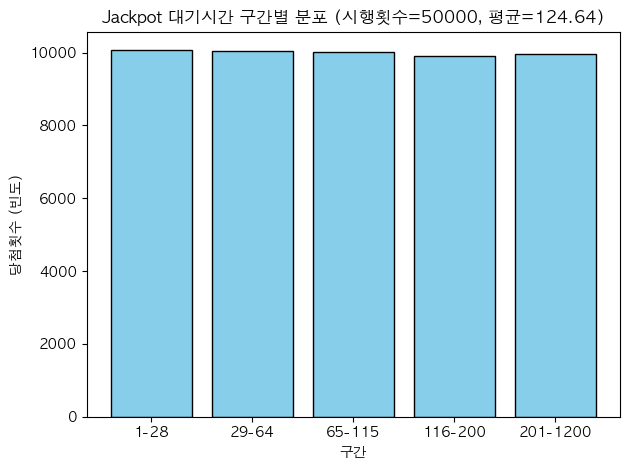

'\n구간분포 지표는 매우 유효하며 구간분포가 차이가 횟수를 거듭해도 특정범위를 벗어나지 않을 확률이 큼을 알수있다.\n'

In [26]:
import random
import matplotlib.pyplot as plt

# ===== 함수 정의 =====
def make_jackpot_num():
    jackpot_num = 1
    while True:
        num = random.randint(1, 125)
        if num == 1:
            return jackpot_num
        else:
            jackpot_num += 1

def calculate_average(num_list):
    if len(num_list) == 0:
        return 0
    return sum(num_list) / len(num_list)

# ===== 실행 =====
N = int(input("시행 횟수를 입력하세요: "))
jackpot_num_list = []

for i in range(N):
    jackpot_num = make_jackpot_num()
    jackpot_num_list.append(jackpot_num)

# 평균 계산
average = calculate_average(jackpot_num_list)
print("평균:", round(average, 2))

# ===== 구간 분류 =====
intervals = [(1, 28), (29, 64), (65, 115), (116, 200), (201, 1200)]
interval_labels = [f"{a}-{b}" for a, b in intervals]
interval_counts = [0] * len(intervals)

for num in jackpot_num_list:
    for i, (a, b) in enumerate(intervals):
        if a <= num <= b:
            interval_counts[i] += 1
            break

print("구간별 개수:", interval_counts)

# ===== 시각화 =====
plt.bar(interval_labels, interval_counts, color='skyblue', edgecolor='black')
plt.xlabel("구간")
plt.ylabel("당첨횟수 (빈도)")
plt.title(f"Jackpot 대기시간 구간별 분포 (시행횟수={N}, 평균={average:.2f})")
plt.tight_layout()
plt.show()

'''
구간분포 지표는 매우 유효하며 구간분포가 차이가 횟수를 거듭해도 특정범위를 벗어나지 않을 확률이 큼을 알수있다.
'''

# 유효한 지표들로 임베딩벡터 확정

In [27]:
import random
import math

# ----- 기본 설정 -----
p = 1/125          # 한 번에 잭팟이 날 확률
q = 1 - p          # 한 번에 잭팟이 안 날 확률

total = int(input("얼마를 충전하시겠습니까? "))
jackpot_num_list = []
previous_betting = 0

def make_jackpot_num():
    jackpot_num = 1
    while True:
        num = random.randint(1, 125)
        if num == 1:
            return jackpot_num
        else:
            jackpot_num += 1

def slot_machine():
    global total, previous_betting, jackpot_num_list, interval_counts, probability, forget
    jackpot_num = make_jackpot_num()
    play_num = 0

    # 공통 구간 정의(포함 범위)
    intervals = [(1, 28), (29, 64), (65, 115), (116, 200), (201, 1200)]

    while True:
        betting_str = input("얼마를 배팅 하시겠습니까?")

        if betting_str == '':
            if previous_betting == 0:
                print("이전 배팅 금액이 없습니다. 배팅 금액을 입력해주세요.")
                continue
            else:
                betting = previous_betting
        else:
            try:
                betting = int(betting_str)
                if betting <= 0:
                    print("배팅 금액은 0보다 커야 합니다.")
                    continue
            except ValueError:
                print("유효한 배팅 금액을 입력해주세요.")
                continue

        if betting > total:
            print("배팅 금액이 잔액을 초과합니다.")
            continue

        previous_betting = betting
        play_num += 1
        total -= betting

        # ✅ 기하분포 CDF (정확식): k회 이내에 최소 1회 당첨될 확률
        probability = (1 - (q ** play_num)) * 100

        # 최근 5개 구간 분포
        last_five = jackpot_num_list[-5:]
        interval_counts = [0] * len(intervals)
        for num in last_five:
            for i, (lo, hi) in enumerate(intervals):
                if lo <= num <= hi:
                    interval_counts[i] += 1
                    break

        # 최근 5개 평균
        if len(jackpot_num_list) > 0:
            average_5 = round(sum(jackpot_num_list[-5:]) / len(jackpot_num_list[-5:]))
        else:
            average_5 = 0

        # '사라지는 구간' (뒤에서 다섯 번째가 속한 구간)
        forget = 0
        if len(jackpot_num_list) >= 5:
            fifth_from_last = jackpot_num_list[-5]
            for idx, (lo, hi) in enumerate(intervals, start=1):
                if lo <= fifth_from_last <= hi:
                    forget = idx
                    break

        print("\n")
        print(f"현재 {play_num}회 배팅 중입니다. total: {total}")
        print(f"구간분포 {interval_counts} 누적 당첨확률(CDF) {probability:.2f}%  최근5평균 {average_5}")
        print(f"(1,28)(29,64)(65,115)(116,200)(201), 이전{jackpot_num_list[-5:]} 사라지는구간{forget}")

        if play_num == jackpot_num:
            total += betting * 110
            jackpot_num_list.append(play_num)
            average = round(sum(jackpot_num_list) / len(jackpot_num_list))
            print(f"이야~ 대박!🧞‍♂️ 축하합니다! 잭팟입니다! total: {total}, 평균 = {average}")
            print("🧚 ‍ 🧚‍♀️️")
            break

while True:
    slot_machine()


얼마를 충전하시겠습니까?  50000
얼마를 배팅 하시겠습니까? 10




현재 1회 배팅 중입니다. total: 49990
구간분포 [0, 0, 0, 0, 0] 누적 당첨확률(CDF) 0.80%  최근5평균 0
(1,28)(29,64)(65,115)(116,200)(201), 이전[] 사라지는구간0


KeyboardInterrupt: Interrupted by user

# 임베딩벡터 생성 포함코드

In [44]:
import random
import math

# ----- 확률 파라미터 -----
p = 1 / 125          # 한 번에 잭팟이 날 확률
q = 1 - p            # 한 번에 잭팟이 안 날 확률

total = int(input("얼마를 충전하시겠습니까? "))
jackpot_num_list = []
previous_betting = 0
embedding_vectors = []   # ✅ 모든 플레이의 임베딩 벡터 누적 저장

# 구간 정의(양끝 포함)
intervals = [(1, 28), (29, 64), (65, 115), (116, 200), (201, 1200)]

def make_jackpot_num():
    """기하분포(p=1/125)를 시뮬레이션해서 첫 잭팟 시점을 반환"""
    jackpot_num = 1
    while True:
        num = random.randint(1, 125)
        if num == 1:
            return jackpot_num
        else:
            jackpot_num += 1

def classify_interval(x, intervals):
    """값 x가 속한 구간의 인덱스(0~len-1)를 반환. 없으면 None"""
    for i, (lo, hi) in enumerate(intervals):
        if lo <= x <= hi:
            return i
    return None

def signed_streaks_by_interval(nums, intervals):
    """
    각 구간의 '부호 있는 스트릭' 계산.
      +k : 최근 k세션 연속 '출현'
      -k : 최근 k세션 연속 '미출현'
       0 : 데이터 없음(초기)
    nums는 과거→현재 순서의 jackpot_num 리스트.
    """
    seq = [classify_interval(x, intervals) for x in nums]
    m = len(intervals)
    L = len(seq)
    if L == 0:
        return [0] * m

    streaks = []
    for target in range(m):
        if seq[-1] == target:
            # 최근에 바로 출현 → 연속 출현 길이(양수)
            r = 0
            j = L - 1
            while j >= 0 and seq[j] == target:
                r += 1
                j -= 1
            streaks.append(+r)
        else:
            # 최근에 안 나옴 → 해당 구간이 나오기 전까지의 거리(음수)
            g = 0
            j = L - 1
            while j >= 0 and seq[j] != target:
                g += 1
                j -= 1
            streaks.append(-g)  # 한 번도 안 나왔으면 g == L
    return streaks

def count_last_k_intervals(nums, intervals, k=20):
    """nums의 최근 k개 잭팟이 각 구간에 몇 개 있었는지 카운트"""
    recent = nums[-k:]
    counts = [0] * len(intervals)
    for x in recent:
        idx = classify_interval(x, intervals)
        if idx is not None:
            counts[idx] += 1
    return counts, len(recent)

def build_embedding(interval_counts_5, signed_streaks, last20_counts, average_5, probability):
    """
    17차원 임베딩 벡터 생성:
      [5] 최근5 구간분포 + [5] 구간별 연속정도 + [5] 최근20 구간분포 + [1] 최근5평균 + [1] CDF확률(소수2자리 반올림)
    """
    prob_rounded = round(probability, 2)
    return (
        list(interval_counts_5) +     # 5
        list(signed_streaks) +        # 5
        list(last20_counts) +         # 5
        [average_5, prob_rounded]     # 2
    )

def slot_machine():
    global total, previous_betting, jackpot_num_list, embedding_vectors
    jackpot_num = make_jackpot_num()
    play_num = 0

    while True:
        betting_str = input("얼마를 배팅 하시겠습니까?")

        if betting_str == '':
            if previous_betting == 0:
                print("이전 배팅 금액이 없습니다. 배팅 금액을 입력해주세요.")
                continue
            else:
                betting = previous_betting
        else:
            try:
                betting = int(betting_str)
                if betting <= 0:
                    print("배팅 금액은 0보다 커야 합니다.")
                    continue
            except ValueError:
                print("유효한 배팅 금액을 입력해주세요.")
                continue

        if betting > total:
            print("배팅 금액이 잔액을 초과합니다.")
            continue

        previous_betting = betting
        play_num += 1
        total -= betting

        # ✅ 기하분포 CDF(정확식): k회 이내 최소 1회 잭팟 발생 확률 (%)
        probability = (1 - (q ** play_num)) * 100.0

        # 최근 5개 구간 분포
        last_five = jackpot_num_list[-5:]
        interval_counts_5 = [0] * len(intervals)
        for num in last_five:
            idx = classify_interval(num, intervals)
            if idx is not None:
                interval_counts_5[idx] += 1

        # 최근 5개 평균
        if len(jackpot_num_list) > 0:
            average_5 = round(sum(jackpot_num_list[-5:]) / len(jackpot_num_list[-5:]))
        else:
            average_5 = 0

        # 구간별 부호 있는 스트릭
        signed_streaks = signed_streaks_by_interval(jackpot_num_list, intervals)

        # 최근 20개 잭팟 구간 카운트
        last20_counts, n_recent = count_last_k_intervals(jackpot_num_list, intervals, k=20)

        # 📦 매 플레이마다 임베딩 생성 & 저장 (probability는 소수2자리 반올림하여 저장)
        embedding_vector = build_embedding(interval_counts_5, signed_streaks, last20_counts, average_5, probability)
        embedding_vectors.append(embedding_vector)

        print("\n")
        print(f"현재 {play_num}회 배팅 중입니다. total: {total}")
        print(f"구간분포(최근5) {interval_counts_5}  당첨확률(CDF) {round(probability, 2)}%  최근5평균 {average_5}")
        print(f"구간별 연속정도 : {signed_streaks}")
        print(f"최근 {n_recent}개 구간별 횟수(최대 20개): {last20_counts}")
        print(f"(1,28)(29,64)(65,115)(116,200)(201), 이전{jackpot_num_list[-5:]}")
        print(f"🧩 이번 플레이 임베딩(길이 {len(embedding_vector)}): {embedding_vector}")
        print(f"누적 임베딩 개수: {len(embedding_vectors)}")

        # 잭팟 처리
        if play_num == jackpot_num:
            total += betting * 110
            jackpot_num_list.append(play_num)
            average = round(sum(jackpot_num_list) / len(jackpot_num_list))
            print(f"이야~ 대박!🧞‍♂️ 축하합니다! 잭팟입니다! total: {total}, 평균 = {average}")
            print("🧚 ‍ 🧚‍♀️️")
            break

while True:
    slot_machine()


얼마를 충전하시겠습니까?  50000
얼마를 배팅 하시겠습니까? 10




현재 1회 배팅 중입니다. total: 49990
구간분포(최근5) [0, 0, 0, 0, 0]  당첨확률(CDF) 0.8%  최근5평균 0
구간별 연속정도 : [0, 0, 0, 0, 0]
최근 0개 구간별 횟수(최대 20개): [0, 0, 0, 0, 0]
(1,28)(29,64)(65,115)(116,200)(201), 이전[]
🧩 이번 플레이 임베딩(길이 17): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.8]
누적 임베딩 개수: 1


얼마를 배팅 하시겠습니까? 




현재 2회 배팅 중입니다. total: 49980
구간분포(최근5) [0, 0, 0, 0, 0]  당첨확률(CDF) 1.59%  최근5평균 0
구간별 연속정도 : [0, 0, 0, 0, 0]
최근 0개 구간별 횟수(최대 20개): [0, 0, 0, 0, 0]
(1,28)(29,64)(65,115)(116,200)(201), 이전[]
🧩 이번 플레이 임베딩(길이 17): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1.59]
누적 임베딩 개수: 2


얼마를 배팅 하시겠습니까? 


...

얼마를 배팅 하시겠습니까? 




현재 134회 배팅 중입니다. total: 48660
구간분포(최근5) [0, 0, 0, 0, 0]  당첨확률(CDF) 65.91%  최근5평균 0
구간별 연속정도 : [0, 0, 0, 0, 0]
최근 0개 구간별 횟수(최대 20개): [0, 0, 0, 0, 0]
(1,28)(29,64)(65,115)(116,200)(201), 이전[]
🧩 이번 플레이 임베딩(길이 17): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 65.91]
누적 임베딩 개수: 134


얼마를 배팅 하시겠습니까? 




현재 135회 배팅 중입니다. total: 48650
구간분포(최근5) [0, 0, 0, 0, 0]  당첨확률(CDF) 66.19%  최근5평균 0
구간별 연속정도 : [0, 0, 0, 0, 0]
최근 0개 구간별 횟수(최대 20개): [0, 0, 0, 0, 0]
(1,28)(29,64)(65,115)(116,200)(201), 이전[]
🧩 이번 플레이 임베딩(길이 17): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 66.19]
누적 임베딩 개수: 135


KeyboardInterrupt: Interrupted by user

# 구간연속 분포에 나오는 숫자에 대해 감을 잡고 확률적 강도를 보기위해 젝팟넘 생성을 무수히시켜 빈도를 보고 최대 어느정도 숫자까지 나오는지를 조사

N (생성할 잭팟 개수):  100000



[스트릭값 변화 히스토그램]
 -57: 1
 -56: 1
 -55: 1
 -54: 1
 -53: 2
 -52: 2
 -51: 2
 -50: 2
 -49: 3
 -48: 3
 -47: 3
 -46: 3
 -45: 4
 -44: 6
 -43: 6
 -42: 8
 -41: 9
 -40: 12
 -39: 17
 -38: 19
 -37: 26
 -36: 34
 -35: 46
 -34: 62
 -33: 76
 -32: 92
 -31: 115
 -30: 141
 -29: 170
 -28: 203
 -27: 252
 -26: 326
 -25: 401
 -24: 489
 -23: 603
 -22: 773
 -21: 964
 -20: 1206
 -19: 1493
 -18: 1876
 -17: 2318
 -16: 2868
 -15: 3595
 -14: 4429
 -13: 5509
 -12: 6903
 -11: 8612
 -10: 10729
  -9: 13375
  -8: 16749
  -7: 20854
  -6: 26164
  -5: 32597
  -4: 40892
  -3: 51171
  -2: 63912
  -1: 79871
   1: 79871
   2: 16190
   3: 3196
   4: 610
   5: 100
   6: 24
   7: 3


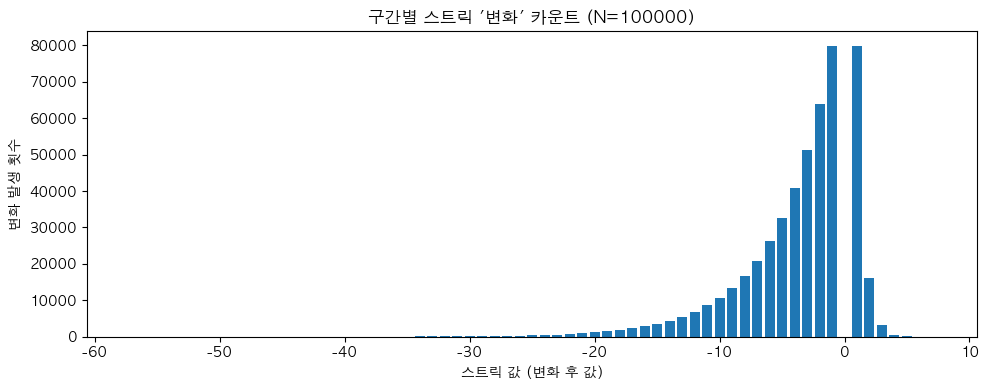

In [43]:
 # ===== 스트릭 변화 카운트 & 막대그래프 =====
# 필요: intervals, make_jackpot_num, classify_interval, signed_streaks_by_interval 가 위에 정의되어 있어야 함.

import matplotlib.pyplot as plt
from collections import defaultdict

def count_streak_changes_and_plot():
    try:
        N = int(input("N (생성할 잭팟 개수): "))
    except:
        N = 5000

    jackpot_num_list_local = []
    prev_streaks = None
    change_counts = defaultdict(int)   # {스트릭값: 등장횟수}

    for _ in range(N):
        j = make_jackpot_num()
        jackpot_num_list_local.append(j)
        cur = signed_streaks_by_interval(jackpot_num_list_local, intervals)

        if prev_streaks is not None:
            # 이전 시점과 달라진 구간만 카운트 (변화가 생긴 부분만 +1)
            for s_prev, s_cur in zip(prev_streaks, cur):
                if s_prev != s_cur:
                    change_counts[s_cur] += 1

        prev_streaks = cur

    # ---- 출력 ----
    if not change_counts:
        print("변화가 감지되지 않았습니다.")
        return

    # 키(스트릭값) 정렬해서 막대그래프
    xs = sorted(change_counts.keys())
    ys = [change_counts[x] for x in xs]

    print("\n[스트릭값 변화 히스토그램]")
    for x in xs:
        print(f"{x:>4}: {change_counts[x]}")

    plt.figure(figsize=(10, 4))
    plt.bar(xs, ys)
    plt.xlabel("스트릭 값 (변화 후 값)")
    plt.ylabel("변화 발생 횟수")
    plt.title(f"구간별 스트릭 '변화' 카운트 (N={N})")
    plt.tight_layout()
    plt.show()

# 실행
if __name__ == "__main__":
    count_streak_changes_and_plot()


# 0. 임베딩벡터 내 요소간의 관계를 공분산과 코사인유사도, norm으로 파악하고 신경망 설계하기

In [ ]:
import numpy as np
from numpy.linalg import norm

# 예: 임베딩 벡터들
X = np.array(embedding_vectors)  # (N, 17)
A = X[:, 0:5]   # 최근5 구간분포
B = X[:, 5:10]  # 스트릭

# 각 시점별 코사인 유사도 계산
cosine_sims = np.sum(A*B, axis=1) / (norm(A, axis=1) * norm(B, axis=1))

print("평균 코사인 유사도:", np.mean(cosine_sims))
print("상위 5개 유사도:", np.sort(cosine_sims)[-5:])


In [47]:
import random
import math
import numpy as np
from numpy.linalg import norm

# ----- 확률 파라미터 -----
p = 1 / 125          # 한 번에 잭팟이 날 확률
q = 1 - p            # 한 번에 잭팟이 안 날 확률

total = int(input("얼마를 충전하시겠습니까? "))
jackpot_num_list = []
previous_betting = 0
embedding_vectors = []   # ✅ 모든 플레이의 임베딩 벡터 누적 저장

# 구간 정의(양끝 포함)
intervals = [(1, 28), (29, 64), (65, 115), (116, 200), (201, 1200)]

def make_jackpot_num():
    """기하분포(p=1/125)를 시뮬레이션해서 첫 잭팟 시점을 반환"""
    jackpot_num = 1
    while True:
        num = random.randint(1, 125)
        if num == 1:
            return jackpot_num
        else:
            jackpot_num += 1

def classify_interval(x, intervals):
    """값 x가 속한 구간의 인덱스(0~len-1)를 반환. 없으면 None"""
    for i, (lo, hi) in enumerate(intervals):
        if lo <= x <= hi:
            return i
    return None

def signed_streaks_by_interval(nums, intervals):
    """
    각 구간의 '부호 있는 스트릭' 계산.
      +k : 최근 k세션 연속 '출현'
      -k : 최근 k세션 연속 '미출현'
       0 : 데이터 없음(초기)
    nums는 과거→현재 순서의 jackpot_num 리스트.
    """
    seq = [classify_interval(x, intervals) for x in nums]
    m = len(intervals)
    L = len(seq)
    if L == 0:
        return [0] * m

    streaks = []
    for target in range(m):
        if seq[-1] == target:
            # 최근에 바로 출현 → 연속 출현 길이(양수)
            r = 0
            j = L - 1
            while j >= 0 and seq[j] == target:
                r += 1
                j -= 1
            streaks.append(+r)
        else:
            # 최근에 안 나옴 → 해당 구간이 나오기 전까지의 거리(음수)
            g = 0
            j = L - 1
            while j >= 0 and seq[j] != target:
                g += 1
                j -= 1
            streaks.append(-g)
    return streaks

def count_last_k_intervals(nums, intervals, k=20):
    """nums의 최근 k개 잭팟이 각 구간에 몇 개 있었는지 카운트"""
    recent = nums[-k:]
    counts = [0] * len(intervals)
    for x in recent:
        idx = classify_interval(x, intervals)
        if idx is not None:
            counts[idx] += 1
    return counts, len(recent)

def build_embedding(interval_counts_5, signed_streaks, last20_counts, average_5, probability):
    """
    17차원 임베딩 벡터 생성:
      [5] 최근5 구간분포 + [5] 구간별 연속정도 + [5] 최근20 구간분포 + [1] 최근5평균 + [1] CDF확률(소수2자리 반올림)
    """
    prob_rounded = round(probability, 2)
    return (
        list(interval_counts_5) +     # 5
        list(signed_streaks) +        # 5
        list(last20_counts) +         # 5
        [average_5, prob_rounded]     # 2
    )

def slot_machine():
    global total, previous_betting, jackpot_num_list, embedding_vectors
    jackpot_num = make_jackpot_num()
    play_num = 0

    while True:
        betting_str = input("얼마를 배팅 하시겠습니까?")

        if betting_str == '':
            if previous_betting == 0:
                print("이전 배팅 금액이 없습니다. 배팅 금액을 입력해주세요.")
                continue
            else:
                betting = previous_betting
        else:
            try:
                betting = int(betting_str)
                if betting <= 0:
                    print("배팅 금액은 0보다 커야 합니다.")
                    continue
            except ValueError:
                print("유효한 배팅 금액을 입력해주세요.")
                continue

        if betting > total:
            print("배팅 금액이 잔액을 초과합니다.")
            continue

        previous_betting = betting
        play_num += 1
        total -= betting

        # ✅ 기하분포 CDF(정확식): k회 이내 최소 1회 잭팟 발생 확률 (%)
        probability = (1 - (q ** play_num)) * 100.0

        # 최근 5개 구간 분포
        last_five = jackpot_num_list[-5:]
        interval_counts_5 = [0] * len(intervals)
        for num in last_five:
            idx = classify_interval(num, intervals)
            if idx is not None:
                interval_counts_5[idx] += 1

        # 최근 5개 평균
        if len(jackpot_num_list) > 0:
            average_5 = round(sum(jackpot_num_list[-5:]) / len(jackpot_num_list[-5:]))
        else:
            average_5 = 0

        # 구간별 부호 있는 스트릭
        signed_streaks = signed_streaks_by_interval(jackpot_num_list, intervals)

        # 최근 20개 잭팟 구간 카운트
        last20_counts, n_recent = count_last_k_intervals(jackpot_num_list, intervals, k=20)

        # 📦 매 플레이마다 임베딩 생성 & 저장
        embedding_vector = build_embedding(interval_counts_5, signed_streaks, last20_counts, average_5, probability)
        embedding_vectors.append(embedding_vector)

        print("\n")
        print(f"현재 {play_num}회 배팅 중입니다. total: {total}")
        print(f"구간분포(최근5) {interval_counts_5}  당첨확률(CDF) {round(probability, 2)}%  최근5평균 {average_5}")
        print(f"구간별 연속정도 : {signed_streaks}")
        print(f"최근 {n_recent}개 구간별 횟수(최대 20개): {last20_counts}")
        print(f"(1,28)(29,64)(65,115)(116,200)(201), 이전{jackpot_num_list[-5:]}")
        print(f"🧩 이번 플레이 임베딩(길이 {len(embedding_vector)}): {embedding_vector}")
        print(f"누적 임베딩 개수: {len(embedding_vectors)}")

        # === ✅ 안전한 코사인 유사도 계산 ===
        X = np.array(embedding_vectors, dtype=float)
        if X.shape[0] > 0:
            A = X[:, 0:5]   # 최근5 구간분포
            B = X[:, 5:10]  # 스트릭

            # 각 벡터의 노름 계산
            normA = norm(A, axis=1)
            normB = norm(B, axis=1)

            # 분모 0 방지
            denominator = normA * normB
            denominator[denominator == 0] = 1e-9

            cosine_sims = np.sum(A * B, axis=1) / denominator
            cosine_sims = np.nan_to_num(cosine_sims, nan=0.0, posinf=0.0, neginf=0.0)

            print("평균 코사인 유사도:", round(np.mean(cosine_sims), 4))
            print("상위 5개 유사도:", np.round(np.sort(cosine_sims)[-5:], 4))
        else:
            print("아직 임베딩 데이터가 부족합니다.")

        # 잭팟 처리
        if play_num == jackpot_num:
            total += betting * 110
            jackpot_num_list.append(play_num)
            average = round(sum(jackpot_num_list) / len(jackpot_num_list))
            print(f"이야~ 대박!🧞‍♂️ 축하합니다! 잭팟입니다! total: {total}, 평균 = {average}")
            print("🧚 ‍ 🧚‍♀️️")
            break

while True:
    slot_machine()


얼마를 충전하시겠습니까?  50000
얼마를 배팅 하시겠습니까? 10




현재 1회 배팅 중입니다. total: 49990
구간분포(최근5) [0, 0, 0, 0, 0]  당첨확률(CDF) 0.8%  최근5평균 0
구간별 연속정도 : [0, 0, 0, 0, 0]
최근 0개 구간별 횟수(최대 20개): [0, 0, 0, 0, 0]
(1,28)(29,64)(65,115)(116,200)(201), 이전[]
🧩 이번 플레이 임베딩(길이 17): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.8]
누적 임베딩 개수: 1
평균 코사인 유사도: 0.0
상위 5개 유사도: [0.]


얼마를 배팅 하시겠습니까? 




현재 2회 배팅 중입니다. total: 49980
구간분포(최근5) [0, 0, 0, 0, 0]  당첨확률(CDF) 1.59%  최근5평균 0
구간별 연속정도 : [0, 0, 0, 0, 0]
최근 0개 구간별 횟수(최대 20개): [0, 0, 0, 0, 0]
(1,28)(29,64)(65,115)(116,200)(201), 이전[]
🧩 이번 플레이 임베딩(길이 17): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1.59]
누적 임베딩 개수: 2
평균 코사인 유사도: 0.0
상위 5개 유사도: [0. 0.]


얼마를 배팅 하시겠습니까? 


...

얼마를 배팅 하시겠습니까? 




현재 118회 배팅 중입니다. total: 49300
구간분포(최근5) [0, 1, 0, 0, 0]  당첨확률(CDF) 61.24%  최근5평균 62
구간별 연속정도 : [-1, 1, -1, -1, -1]
최근 1개 구간별 횟수(최대 20개): [0, 1, 0, 0, 0]
(1,28)(29,64)(65,115)(116,200)(201), 이전[62]
🧩 이번 플레이 임베딩(길이 17): [0, 1, 0, 0, 0, -1, 1, -1, -1, -1, 0, 1, 0, 0, 0, 62, 61.24]
누적 임베딩 개수: 180
평균 코사인 유사도: 0.2932
상위 5개 유사도: [0.4472 0.4472 0.4472 0.4472 0.4472]


얼마를 배팅 하시겠습니까? 




현재 119회 배팅 중입니다. total: 49290
구간분포(최근5) [0, 1, 0, 0, 0]  당첨확률(CDF) 61.55%  최근5평균 62
구간별 연속정도 : [-1, 1, -1, -1, -1]
최근 1개 구간별 횟수(최대 20개): [0, 1, 0, 0, 0]
(1,28)(29,64)(65,115)(116,200)(201), 이전[62]
🧩 이번 플레이 임베딩(길이 17): [0, 1, 0, 0, 0, -1, 1, -1, -1, -1, 0, 1, 0, 0, 0, 62, 61.55]
누적 임베딩 개수: 181
평균 코사인 유사도: 0.294
상위 5개 유사도: [0.4472 0.4472 0.4472 0.4472 0.4472]


KeyboardInterrupt: Interrupted by user

# 1. 무수히 시행시켜 임베딩벡터를 많이 만들어 분포시키고 코사인 유사도를 통해 각 벡터의 대표 벡터를 뽑고 빈도수가 낮은 쪽에 낮은 배팅을 정답으로 제공해 데이터와 레이블 생성

In [48]:
# 군집화로 레이블링 해도되고
# 이 데이터들로 학습한것을 pretrain으로 하고 뒤에서 강화학습으로 finetunning하는 법 생각한다.
# 코사인유사도 0이면 유사도 없는것
# 클러스터링, 산점도 등은 사이킷런이나 케라스등 이용해볼생각 (군집 중심 혹은 대표값 잡아주는 알고리즘있다. 군집화 얼마나 잘됐는지 알려주는 지표 elbow도있고)

In [91]:
import random
import math

# ----- 확률 파라미터 -----
p = 1 / 125          # 한 번에 잭팟이 날 확률
q = 1 - p            # 한 번에 잭팟이 안 날 확률

total = int(input("얼마를 충전하시겠습니까? "))
jackpot_num_list = []
previous_betting = 0
embedding_vectors = []   # ✅ 모든 플레이의 임베딩 벡터 누적 저장

# 구간 정의(양끝 포함)
intervals = [(1, 28), (29, 64), (65, 115), (116, 200), (201, 1200)]

def make_jackpot_num():
    """기하분포(p=1/125)를 시뮬레이션해서 첫 잭팟 시점을 반환"""
    jackpot_num = 1
    while True:
        num = random.randint(1, 125)
        if num == 1:
            return jackpot_num
        else:
            jackpot_num += 1

def classify_interval(x, intervals):
    """값 x가 속한 구간의 인덱스(0~len-1)를 반환. 없으면 None"""
    for i, (lo, hi) in enumerate(intervals):
        if lo <= x <= hi:
            return i
    return None

def signed_streaks_by_interval(nums, intervals):
    """
    각 구간의 '부호 있는 스트릭' 계산.
      +k : 최근 k세션 연속 '출현'
      -k : 최근 k세션 연속 '미출현'
       0 : 데이터 없음(초기)
    nums는 과거→현재 순서의 jackpot_num 리스트.
    """
    seq = [classify_interval(x, intervals) for x in nums]
    m = len(intervals)
    L = len(seq)
    if L == 0:
        return [0] * m

    streaks = []
    for target in range(m):
        if seq[-1] == target:
            # 최근에 바로 출현 → 연속 출현 길이(양수)
            r = 0
            j = L - 1
            while j >= 0 and seq[j] == target:
                r += 1
                j -= 1
            streaks.append(+r)
        else:
            # 최근에 안 나옴 → 해당 구간이 나오기 전까지의 거리(음수)
            g = 0
            j = L - 1
            while j >= 0 and seq[j] != target:
                g += 1
                j -= 1
            streaks.append(-g)
    return streaks

def count_last_k_intervals(nums, intervals, k=20):
    """nums의 최근 k개 잭팟이 각 구간에 몇 개 있었는지 카운트"""
    recent = nums[-k:]
    counts = [0] * len(intervals)
    for x in recent:
        idx = classify_interval(x, intervals)
        if idx is not None:
            counts[idx] += 1
    return counts, len(recent)

def moving_average(data, n):
    """길이가 부족해도 있는 만큼으로 평균"""
    if len(data) == 0:
        return 0
    subset = data[-n:] if len(data) >= n else data
    return round(sum(subset) / len(subset))

def build_embedding(interval_counts_5, signed_streaks, last20_counts, forgotten_bin,
                    avg5, avg10, avg20, probability, play_num, total):
    """
    22차원 임베딩:
      [5] 최근5 구간분포 + [5] 구간별 연속정도 + [5] 최근20 구간분포
      + [1] 사라지는 구간(뒤에서 5번째의 구간: 1~5, 없으면 0)
      + [3] 평균(5/10/20) + [1] CDF확률(%. 소수2자리) + [1] play_num + [1] total
    """
    prob_rounded = round(probability, 2)
    return (
        list(interval_counts_5) +          # 5
        list(signed_streaks) +             # 5
        list(last20_counts) +              # 5
        [forgotten_bin] +                  # 1
        [avg5, avg10, avg20] +             # 3
        [prob_rounded, play_num, total]    # 3
    )

def slot_machine():
    global total, previous_betting, jackpot_num_list, embedding_vectors
    jackpot_num = make_jackpot_num()
    play_num = 0

    while True:
        betting_str = input("얼마를 배팅 하시겠습니까?")

        if betting_str == '':
            if previous_betting == 0:
                print("이전 배팅 금액이 없습니다. 배팅 금액을 입력해주세요.")
                continue
            else:
                betting = previous_betting
        else:
            try:
                betting = int(betting_str)
                if betting <= 0:
                    print("배팅 금액은 0보다 커야 합니다.")
                    continue
            except ValueError:
                print("유효한 배팅 금액을 입력해주세요.")
                continue

        if betting > total:
            print("배팅 금액이 잔액을 초과합니다.")
            continue

        previous_betting = betting
        play_num += 1
        total -= betting

        # ✅ 기하분포 CDF(정확식): k회 이내 최소 1회 잭팟 발생 확률 (%)
        probability = (1 - (q ** play_num)) * 100.0

        # 최근 5개 구간 분포
        last_five = jackpot_num_list[-5:]
        interval_counts_5 = [0] * len(intervals)
        for num in last_five:
            idx = classify_interval(num, intervals)
            if idx is not None:
                interval_counts_5[idx] += 1

        # 최근 평균(5/10/20) — 데이터 부족해도 계산
        average_5  = moving_average(jackpot_num_list, 5)
        average_10 = moving_average(jackpot_num_list, 10)
        average_20 = moving_average(jackpot_num_list, 20)

        # 구간별 부호 있는 스트릭
        signed_streaks = signed_streaks_by_interval(jackpot_num_list, intervals)

        # 최근 20개 잭팟 구간 카운트
        last20_counts, n_recent = count_last_k_intervals(jackpot_num_list, intervals, k=20)

        # 🧭 사라지는 구간(뒤에서 5번째 값이 속한 구간: 1~5, 없으면 0)
        if len(jackpot_num_list) >= 5:
            fifth_from_last = jackpot_num_list[-5]
            fi = classify_interval(fifth_from_last, intervals)
            forgotten_bin = (fi + 1) if fi is not None else 0
        else:
            forgotten_bin = 0

        # 🧩 매 플레이마다 임베딩 생성 & 저장 (총 22차원)
        embedding_vector = build_embedding(
            interval_counts_5, signed_streaks, last20_counts, forgotten_bin,
            average_5, average_10, average_20,
            probability, play_num, total
        )
        embedding_vectors.append(embedding_vector)

        print("\n")
        print(f"현재 {play_num}회 배팅 중입니다. total: {total}")
        print(f"구간분포(최근5) {interval_counts_5}  당첨확률(CDF) {round(probability, 2)}%")
        print(f"최근 평균: 5개={average_5}, 10개={average_10}, 20개={average_20}")
        print(f"구간별 연속정도 : {signed_streaks}")
        print(f"최근 {n_recent}개 구간별 횟수(최대 20개): {last20_counts}")
        print(f"사라지는 구간: {forgotten_bin}  (1~5, 데이터 부족/해당없음=0)")
        print(f"(1,28)(29,64)(65,115)(116,200)(201), 이전{jackpot_num_list[-5:]}")
        print(f"🧩 이번 플레이 임베딩(길이 {len(embedding_vector)}): {embedding_vector}")
        print(f"누적 임베딩 개수: {len(embedding_vectors)}")

        # 잭팟 처리
        if play_num == jackpot_num:
            total += betting * 110
            jackpot_num_list.append(play_num)
            average_all = round(sum(jackpot_num_list) / len(jackpot_num_list))
            print(f"이야~ 대박!🧞‍♂️ 축하합니다! 잭팟입니다! total: {total}, 전체 평균 = {average_all}")
            print("🧚‍♂️ 🧚‍♀️")
            break

while True:
    slot_machine()


얼마를 충전하시겠습니까?  50000
얼마를 배팅 하시겠습니까? 10




현재 1회 배팅 중입니다. total: 49990
구간분포(최근5) [0, 0, 0, 0, 0]  당첨확률(CDF) 0.8%
최근 평균: 5개=0, 10개=0, 20개=0
구간별 연속정도 : [0, 0, 0, 0, 0]
최근 0개 구간별 횟수(최대 20개): [0, 0, 0, 0, 0]
사라지는 구간: 0  (1~5, 데이터 부족/해당없음=0)
(1,28)(29,64)(65,115)(116,200)(201), 이전[]
🧩 이번 플레이 임베딩(길이 22): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.8, 1, 49990]
누적 임베딩 개수: 1
이야~ 대박!🧞‍♂️ 축하합니다! 잭팟입니다! total: 51090, 전체 평균 = 1
🧚‍♂️ 🧚‍♀️


얼마를 배팅 하시겠습니까? 




현재 1회 배팅 중입니다. total: 51080
구간분포(최근5) [1, 0, 0, 0, 0]  당첨확률(CDF) 0.8%
최근 평균: 5개=1, 10개=1, 20개=1
구간별 연속정도 : [1, -1, -1, -1, -1]
최근 1개 구간별 횟수(최대 20개): [1, 0, 0, 0, 0]
사라지는 구간: 0  (1~5, 데이터 부족/해당없음=0)
(1,28)(29,64)(65,115)(116,200)(201), 이전[1]
🧩 이번 플레이 임베딩(길이 22): [1, 0, 0, 0, 0, 1, -1, -1, -1, -1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0.8, 1, 51080]
누적 임베딩 개수: 2


얼마를 배팅 하시겠습니까? 


...

얼마를 배팅 하시겠습니까? 




현재 4회 배팅 중입니다. total: 51050
구간분포(최근5) [1, 0, 0, 0, 0]  당첨확률(CDF) 3.16%
최근 평균: 5개=1, 10개=1, 20개=1
구간별 연속정도 : [1, -1, -1, -1, -1]
최근 1개 구간별 횟수(최대 20개): [1, 0, 0, 0, 0]
사라지는 구간: 0  (1~5, 데이터 부족/해당없음=0)
(1,28)(29,64)(65,115)(116,200)(201), 이전[1]
🧩 이번 플레이 임베딩(길이 22): [1, 0, 0, 0, 0, 1, -1, -1, -1, -1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 3.16, 4, 51050]
누적 임베딩 개수: 5


얼마를 배팅 하시겠습니까? 




현재 5회 배팅 중입니다. total: 51040
구간분포(최근5) [1, 0, 0, 0, 0]  당첨확률(CDF) 3.94%
최근 평균: 5개=1, 10개=1, 20개=1
구간별 연속정도 : [1, -1, -1, -1, -1]
최근 1개 구간별 횟수(최대 20개): [1, 0, 0, 0, 0]
사라지는 구간: 0  (1~5, 데이터 부족/해당없음=0)
(1,28)(29,64)(65,115)(116,200)(201), 이전[1]
🧩 이번 플레이 임베딩(길이 22): [1, 0, 0, 0, 0, 1, -1, -1, -1, -1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 3.94, 5, 51040]
누적 임베딩 개수: 6


KeyboardInterrupt: Interrupted by user

In [ ]:
# 위 차원의 임베딩 벡터에 거의 모든 데이터와 케이스가 담기려면 적어도 몇번의 수행을 해야하는지 계산해보고 학습에 필요한 최적의 데이터는 몇개일지도 추정하여 데이터를 생산한다.
'''
데이터를 생성하는데 데이터를 만들고 각 영역별로 잘라 군집화등으로 데이터 처리해서 어텐션헤드개수와 노드수 층의 깊이로 최적의 신경망 설계한다.
군집화 알고리즘 후보 = DB scan, knn, u-map, t-SNE
효율적인 군집화를 위해 임베딩벡터의 요소별 상관관계 = PCA(차원축소시)
'''

In [2]:
import random
import math
import pandas as pd

# ----- 확률 파라미터 -----
p = 1 / 125
q = 1 - p

# ----- 구간 정의 -----
intervals = [(1, 28), (29, 64), (65, 115), (116, 200), (201, 1200)]

# ----- 함수 정의 -----
def make_jackpot_num():
    """기하분포(p=1/125)를 시뮬레이션해서 첫 잭팟 시점을 반환"""
    jackpot_num = 1
    while True:
        if random.randint(1, 125) == 1:
            return jackpot_num
        jackpot_num += 1

def classify_interval(x, intervals):
    for i, (lo, hi) in enumerate(intervals):
        if lo <= x <= hi:
            return i
    return None

def signed_streaks_by_interval(nums, intervals):
    seq = [classify_interval(x, intervals) for x in nums]
    m = len(intervals)
    L = len(seq)
    if L == 0:
        return [0] * m
    streaks = []
    for target in range(m):
        if seq[-1] == target:
            r = 0
            j = L - 1
            while j >= 0 and seq[j] == target:
                r += 1
                j -= 1
            streaks.append(+r)
        else:
            g = 0
            j = L - 1
            while j >= 0 and seq[j] != target:
                g += 1
                j -= 1
            streaks.append(-g)
    return streaks

def count_last_k_intervals(nums, intervals, k=20):
    recent = nums[-k:]
    counts = [0] * len(intervals)
    for x in recent:
        idx = classify_interval(x, intervals)
        if idx is not None:
            counts[idx] += 1
    return counts, len(recent)

def moving_average(data, n):
    if len(data) == 0:
        return 0
    subset = data[-n:] if len(data) >= n else data
    return round(sum(subset) / len(subset))

def build_embedding(interval_counts_5, signed_streaks, last20_counts, forgotten_bin,
                    avg5, avg10, avg20, probability, play_num, total):
    return (
        list(interval_counts_5) +          # 0~4
        list(signed_streaks) +             # 5~9
        list(last20_counts) +              # 10~14
        [forgotten_bin] +                  # 15
        [avg5, avg10, avg20] +             # 16~18
        [round(probability,2), play_num, total]  # 19~21
    )

# ----- 자동 시뮬레이션 -----
embedding_vectors = []
jackpot_num_list = []
total = 10000000  # 임의의 큰 값 (베팅 걱정 없이)

for _ in range(10000):  # 1만회 자동 시뮬
    jackpot_num = make_jackpot_num()
    play_num = jackpot_num  # 실제 잭팟 도달 시점
    total -= 100  # 배팅 가정
    probability = (1 - (q ** play_num)) * 100.0

    # 최근 5회 구간 분포
    last_five = jackpot_num_list[-5:]
    interval_counts_5 = [0] * len(intervals)
    for num in last_five:
        idx = classify_interval(num, intervals)
        if idx is not None:
            interval_counts_5[idx] += 1

    # 평균들
    avg5 = moving_average(jackpot_num_list, 5)
    avg10 = moving_average(jackpot_num_list, 10)
    avg20 = moving_average(jackpot_num_list, 20)

    # 스트릭, 20개 카운트
    signed_streaks = signed_streaks_by_interval(jackpot_num_list, intervals)
    last20_counts, _ = count_last_k_intervals(jackpot_num_list, intervals, k=20)

    # 사라지는 구간
    if len(jackpot_num_list) >= 5:
        fi = classify_interval(jackpot_num_list[-5], intervals)
        forgotten_bin = (fi + 1) if fi is not None else 0
    else:
        forgotten_bin = 0

    # 임베딩 생성
    emb = build_embedding(interval_counts_5, signed_streaks, last20_counts,
                          forgotten_bin, avg5, avg10, avg20,
                          probability, play_num, total)
    embedding_vectors.append(emb)
    jackpot_num_list.append(play_num)

# ----- 원하는 요소(0~9,15,16~18,19) 추출 -----
selected = [i for i in range(0, 10)] + [15, 16, 17, 18, 19]
filtered_vectors = [[vec[i] for i in selected] for vec in embedding_vectors]

# ----- DataFrame 변환 -----
df = pd.DataFrame(filtered_vectors,
                  columns=[f"F{i}" for i in selected])
print(df.head())

# CSV로 저장 가능
df.to_csv("jackpot_embeddings_filtered.csv", index=False)
print("\n✅ 1만회 임베딩 추출 완료 — 저장됨: jackpot_embeddings_filtered.csv")


   F0  F1  F2  F3  F4  F5  F6  F7  F8  F9  F15  F16  F17  F18    F19
0   0   0   0   0   0   0   0   0   0   0    0    0    0    0  62.16
1   0   0   0   1   0  -1  -1  -1   1  -1    0  121  121  121   0.80
2   1   0   0   1   0   1  -2  -2  -1  -2    0   61   61   61  88.48
3   1   0   0   1   1  -1  -3  -3  -2   1    0  130  130  130  62.77
4   1   0   0   2   1  -2  -4  -4   1  -1    0  128  128  128  47.83

✅ 1만회 임베딩 추출 완료 — 저장됨: jackpot_embeddings_filtered.csv


In [ ]:
# 생성한 임베딩벡터의 원하는 부분을 추출해 u-map과 db-scan으로 차원축소해 군집화 시각화

/opt/anaconda3/envs/umap_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/umap_env/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


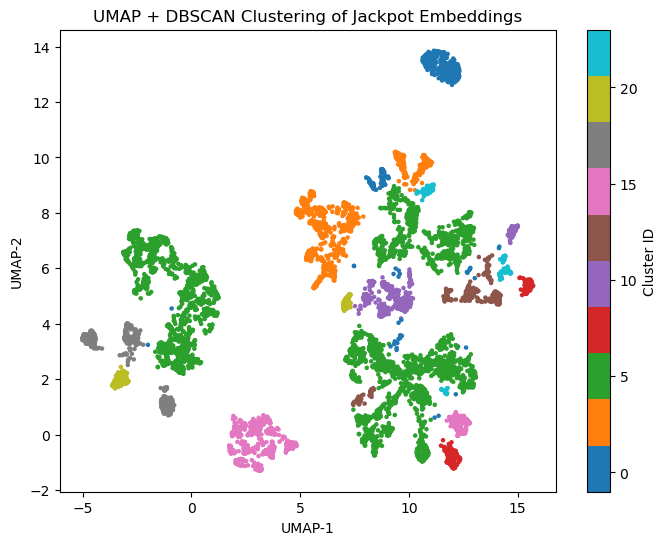

In [4]:
import pandas as pd
import umap
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. 데이터 로드
df = pd.read_csv("jackpot_embeddings_filtered.csv")

# 2. 표준화 (스케일 차이 제거)
X = StandardScaler().fit_transform(df)

# 3. 차원 축소 (UMAP)
reducer = umap.UMAP(n_neighbors=20, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X)

# 4. 군집화 (DBSCAN)
db = DBSCAN(eps=0.3, min_samples=10)
labels = db.fit_predict(X_umap)

# 5. 결과 시각화
plt.figure(figsize=(8,6))
plt.scatter(X_umap[:,0], X_umap[:,1], c=labels, cmap='tab10', s=5)
plt.title("UMAP + DBSCAN Clustering of Jackpot Embeddings")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.colorbar(label="Cluster ID")
plt.show()


/opt/anaconda3/envs/umap_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/umap_env/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


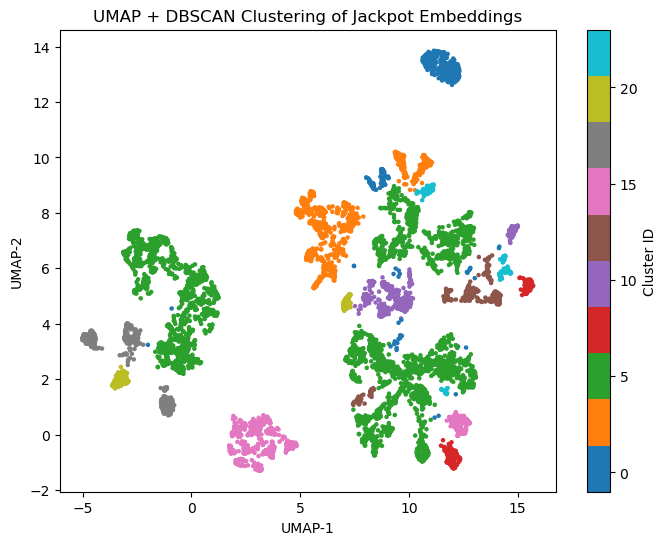

✅ DBSCAN 군집 라벨 추가 완료

🔹 클러스터별 데이터 개수:
cluster
 4     1959
 5     1731
 6     1099
 2      929
 15     715
 9      480
 1      428
 11     340
 3      311
 16     208
 14     199
 18     191
 17     189
 7      176
 19     172
 8      144
 0      142
 10     126
 20     118
 21     115
 23      94
 12      47
 13      42
-1       35
 22      10
Name: count, dtype: int64 

🔹 각 클러스터 평균 임베딩 벡터:

               F0        F1        F2        F3        F4         F5  \
cluster                                                                
-1       0.885714  1.314286  0.514286  0.257143  1.971429  -4.771429   
 0       1.422535  0.000000  1.267606  1.260563  0.992958  -2.887324   
 1       0.997664  0.997664  0.997664  1.000000  0.997664  -1.691589   
 2       1.594187  1.257266  0.000000  0.742734  1.401507  -1.649085   
 3       1.009646  0.000000  1.491961  1.498392  1.000000  -1.131833   
 4       0.000510  1.063298  1.103624  1.129658  1.702910  -8.723839   
 5       1.816291  1.120162  

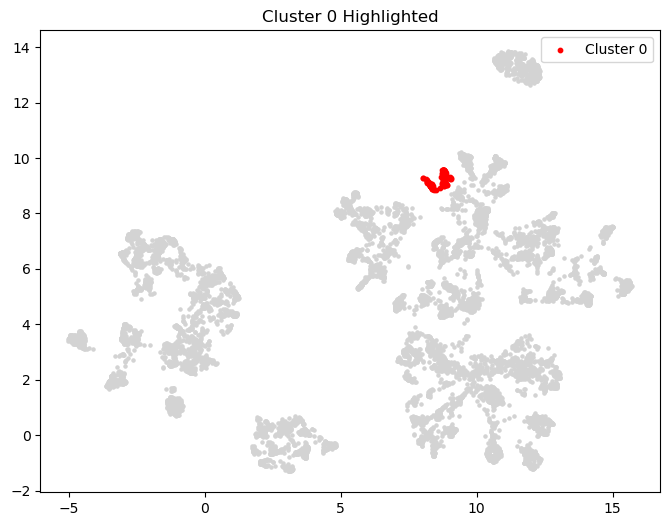

In [5]:
import pandas as pd
import umap
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# =============================
# 1. 데이터 로드
# =============================
df = pd.read_csv("jackpot_embeddings_filtered.csv")

# =============================
# 2. 표준화 (스케일 차이 제거)
# =============================
X = StandardScaler().fit_transform(df)

# =============================
# 3. 차원 축소 (UMAP)
# =============================
reducer = umap.UMAP(n_neighbors=20, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X)

# =============================
# 4. 군집화 (DBSCAN)
# =============================
db = DBSCAN(eps=0.3, min_samples=10)
labels = db.fit_predict(X_umap)

# =============================
# 5. 결과 시각화
# =============================
plt.figure(figsize=(8,6))
plt.scatter(X_umap[:,0], X_umap[:,1], c=labels, cmap='tab10', s=5)
plt.title("UMAP + DBSCAN Clustering of Jackpot Embeddings")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.colorbar(label="Cluster ID")
plt.show()

# =============================
# 6. 클러스터 라벨 추가
# =============================
df['cluster'] = labels
print("✅ DBSCAN 군집 라벨 추가 완료\n")

# =============================
# 7. 군집별 개수 요약
# =============================
print("🔹 클러스터별 데이터 개수:")
print(df['cluster'].value_counts(), "\n")

# =============================
# 8. 각 군집의 평균 패턴 확인
# =============================
cluster_means = df.groupby('cluster').mean()
print("🔹 각 클러스터 평균 임베딩 벡터:\n")
print(cluster_means, "\n")

# =============================
# 9. 특정 군집(색깔) 벡터만 보기
# =============================
target_cluster = 0  # 🔸원하는 색깔(클러스터 ID)을 여기서 지정하세요
df_target = df[df['cluster'] == target_cluster]
print(f"🔹 Cluster {target_cluster}에 속한 임베딩 벡터 {len(df_target)}개 예시:\n")
print(df_target.head(10))

# =============================
# 10. 특정 클러스터만 강조 시각화
# =============================
mask = labels == target_cluster
plt.figure(figsize=(8,6))
plt.scatter(X_umap[:,0], X_umap[:,1], c='lightgray', s=5)
plt.scatter(X_umap[mask,0], X_umap[mask,1], c='red', s=10, label=f"Cluster {target_cluster}")
plt.title(f"Cluster {target_cluster} Highlighted")
plt.legend()
plt.show()


In [ ]:
'''
1. 이렇게 찾게된 군집은 추출된 임베딩벡터의 차원상에서 각각 가까운거리에 있다는 것인데 이것은 사람이 배팅할때 상황을 판단하는것과는 다소 거리가있다
각 지표의 공통된 특성인 빈도수를 고유벡터(고정된 특징축)으로 하여 모든 지표를 공통된 잣대로 분류 비교 가능하게 되는데 그렇다면 이때 구간별 횟수도 이런식으로 빈도관점에서 볼수있도록
재지표화 하고 total도 표준화하여 일정비율로 안정성을 고려하여 비율배팅하도록한다. 
1-1. 병렬처리로 각 지표들을 비교하여 드문상황이 발생했음을 인식하도록? 관련된 임베딩 요소끼리 묶어서 학습시켜 다른 임베딩과 학습되도록

2. 고유벡터의 방향이 그래디언트가 거의 0인 고정된 특징벡터인데 이 고유벡터 개념은 신경망을 지나 변환을 해도 변하지않은 특성이 있는것으로 이러한 부분을 drop out하여 계산효율을 높일수있다.

3.
'''

In [ ]:
# 먼저 분류하는 대략적 신경망 만들고 데이터 들어가면 배팅하게해서 수익이 어떻게 나는지에 따라 finetunning하며 강화학습?

# 안되겠다 지표를 현실적으로 분석하여 확률이라는 공통된 잣대로 지표들을 통합하자

# 1.임베딩벡터의 0~4요소 (구간분포)

In [14]:
import random
from collections import Counter
import pandas as pd

# ----- 확률 파라미터 -----
p = 1 / 125
q = 1 - p

# ----- 구간 정의 (양끝 포함) -----
intervals = [(1, 28), (29, 64), (65, 115), (116, 200), (201, 1200)]

# ----- 잭팟 발생 시점 (기하분포 기반) -----
def make_jackpot_num():
    jackpot_num = 1
    while True:
        if random.randint(1, 125) == 1:
            return jackpot_num
        jackpot_num += 1

# ----- 어떤 값이 어느 구간에 속하는지 -----
def classify_interval(x, intervals):
    for i, (lo, hi) in enumerate(intervals):
        if lo <= x <= hi:
            return i
    return None

# ----- 최근 n개의 잭팟으로 구간분포(히스토그램) 계산 -----
def interval_histogram(nums, intervals, n=5):
    recent = nums[-n:]
    counts = [0] * len(intervals)
    for x in recent:
        idx = classify_interval(x, intervals)
        if idx is not None:
            counts[idx] += 1
    return tuple(counts)

# ----- 시뮬레이션 -----
def simulate_pattern_counts(n_jackpots=10000, window_size=5):
    jackpot_nums = []
    pattern_counter = Counter()

    for _ in range(n_jackpots):
        jackpot = make_jackpot_num()
        jackpot_nums.append(jackpot)

        if len(jackpot_nums) >= window_size:
            pattern = interval_histogram(jackpot_nums, intervals, n=window_size)
            pattern_counter[pattern] += 1

    return pattern_counter

# ----- 실행 -----
n = int(input("생성할 잭팟 개수를 입력하세요: "))
pattern_counts = simulate_pattern_counts(n)

# ----- DataFrame으로 정리 (등장횟수 내림차순) -----
df = pd.DataFrame(
    [(pattern, count) for pattern, count in pattern_counts.items()],
    columns=["Pattern", "Count"]
).sort_values("Count", ascending=False).reset_index(drop=True)

# ----- 전체 출력 -----
pd.set_option("display.max_rows", None)  # 모든 행 출력
print("\n=== 전체 구간분포 패턴 등장 빈도 ===")
print(df)

print(f"\n✅ 총 {len(df)}가지 패턴이 등장했습니다.")


생성할 잭팟 개수를 입력하세요:  10000



=== 전체 구간분포 패턴 등장 빈도 ===
             Pattern  Count
0    (1, 1, 1, 1, 1)    364
1    (1, 0, 1, 1, 2)    224
2    (1, 2, 1, 1, 0)    217
3    (1, 1, 0, 1, 2)    217
4    (0, 1, 1, 1, 2)    212
5    (0, 2, 1, 1, 1)    208
6    (2, 0, 1, 1, 1)    207
7    (1, 0, 2, 1, 1)    204
8    (1, 1, 1, 0, 2)    199
9    (2, 1, 0, 1, 1)    195
10   (1, 1, 1, 2, 0)    194
11   (1, 0, 1, 2, 1)    194
12   (0, 1, 2, 1, 1)    192
13   (0, 1, 1, 2, 1)    184
14   (1, 1, 0, 2, 1)    183
15   (2, 1, 1, 1, 0)    181
16   (1, 2, 1, 0, 1)    176
17   (1, 1, 2, 0, 1)    174
18   (2, 1, 1, 0, 1)    169
19   (1, 1, 2, 1, 0)    165
20   (1, 2, 0, 1, 1)    153
21   (2, 0, 0, 1, 2)    121
22   (2, 0, 0, 2, 1)    115
23   (2, 0, 1, 2, 0)    115
24   (0, 1, 0, 2, 2)    113
25   (2, 0, 2, 1, 0)    112
26   (2, 1, 0, 2, 0)    112
27   (1, 2, 0, 2, 0)    109
28   (2, 0, 1, 0, 2)    109
29   (0, 1, 2, 0, 2)    102
30   (0, 2, 0, 1, 2)    101
31   (1, 0, 2, 2, 0)    101
32   (0, 2, 1, 2, 0)    100
33   (2, 1, 0, 0, 2)  

In [22]:
import random
from collections import Counter
import pandas as pd

# ----- 확률 파라미터 -----
p = 1 / 125
q = 1 - p

# ✅ 구간 정의 (마지막 구간을 무한대로 확장)
intervals = [
    (1, 28),
    (29, 64),
    (65, 115),
    (116, 200),
    (201, float('inf'))  # ← 수정된 부분
]

# ----- 잭팟 발생 시점 (기하분포 기반) -----
def make_jackpot_num():
    jackpot_num = 1
    while True:
        if random.randint(1, 125) == 1:
            return jackpot_num
        jackpot_num += 1

# ----- 어떤 값이 어느 구간에 속하는지 -----
def classify_interval(x, intervals):
    for i, (lo, hi) in enumerate(intervals):
        if lo <= x <= hi:
            return i
    return None

# ----- 최근 n개의 잭팟으로 구간분포(히스토그램) 계산 -----
def interval_histogram(nums, intervals, n=5):
    recent = nums[-n:]
    counts = [0] * len(intervals)
    for x in recent:
        idx = classify_interval(x, intervals)
        if idx is not None:
            counts[idx] += 1
    return tuple(counts)

# ----- 시뮬레이션 -----
def simulate_pattern_counts(n_jackpots=10000, window_size=5):
    jackpot_nums = []
    pattern_counter = Counter()

    for _ in range(n_jackpots):
        jackpot = make_jackpot_num()
        jackpot_nums.append(jackpot)

        if len(jackpot_nums) >= window_size:
            pattern = interval_histogram(jackpot_nums, intervals, n=window_size)
            if sum(pattern) == window_size:  # 이 부분 그대로 유지
                pattern_counter[pattern] += 1

    return pattern_counter

# ----- 실행 -----
n = int(input("생성할 잭팟 개수를 입력하세요: "))
pattern_counts = simulate_pattern_counts(n)

# ----- DataFrame으로 정리 (등장횟수 내림차순) -----
total = sum(pattern_counts.values())

df = pd.DataFrame(
    [(pattern, count, count / total * 100) for pattern, count in pattern_counts.items()],
    columns=["Pattern", "Count", "Probability(%)"]
).sort_values("Probability(%)", ascending=False).reset_index(drop=True)

# ----- 전체 출력 -----
pd.set_option("display.max_rows", None)
print("\n=== 전체 구간분포 패턴 등장 확률 (%) ===")
print(df)

print(f"\n✅ 총 {len(df)}가지 패턴이 등장했습니다. (전체 {total}회)")

# 상위 30개정도가 50%를 차지한다.

생성할 잭팟 개수를 입력하세요:  200000



=== 전체 구간분포 패턴 등장 확률 (%) ===
             Pattern  Count  Probability(%)
0    (1, 1, 1, 1, 1)   7727        3.863577
1    (0, 1, 1, 2, 1)   3975        1.987540
2    (2, 1, 1, 0, 1)   3967        1.983540
3    (1, 2, 1, 0, 1)   3929        1.964539
4    (1, 1, 0, 1, 2)   3925        1.962539
5    (2, 0, 1, 1, 1)   3924        1.962039
6    (1, 1, 2, 0, 1)   3919        1.959539
7    (1, 0, 1, 1, 2)   3906        1.953039
8    (1, 2, 0, 1, 1)   3899        1.949539
9    (2, 1, 1, 1, 0)   3870        1.935039
10   (1, 1, 1, 0, 2)   3859        1.929539
11   (2, 1, 0, 1, 1)   3810        1.905038
12   (1, 2, 1, 1, 0)   3793        1.896538
13   (1, 1, 2, 1, 0)   3779        1.889538
14   (1, 0, 2, 1, 1)   3774        1.887038
15   (0, 1, 2, 1, 1)   3732        1.866037
16   (1, 1, 0, 2, 1)   3711        1.855537
17   (0, 2, 1, 1, 1)   3709        1.854537
18   (1, 0, 1, 2, 1)   3693        1.846537
19   (0, 1, 1, 1, 2)   3680        1.840037
20   (1, 1, 1, 2, 0)   3675        1.837537
21

In [20]:
import random

# ----- 확률 파라미터 -----
p = 1 / 125
q = 1 - p

# ----- 잭팟 생성 함수 -----
def make_jackpot_num():
    """기하분포(p=1/125)로 잭팟 시점 하나 생성"""
    jackpot_num = 1
    while True:
        if random.randint(1, 125) == 1:
            return jackpot_num
        jackpot_num += 1

# ----- 여러 번 시뮬레이션 -----
n = int(input("생성할 잭팟 개수를 입력하세요: "))

jackpot_nums = [make_jackpot_num() for _ in range(n)]

# ----- 결과 출력 -----
print(f"\n생성된 잭팟 시점 중 최대값: {max(jackpot_nums)}")
print(f"전체 잭팟 평균: {sum(jackpot_nums)/len(jackpot_nums):.2f}")
print(f"상위 10개 잭팟 시점: {sorted(jackpot_nums, reverse=True)[:10]}")


생성할 잭팟 개수를 입력하세요:  100000



생성된 잭팟 시점 중 최대값: 1788
전체 잭팟 평균: 124.80
상위 10개 잭팟 시점: [1788, 1679, 1508, 1494, 1253, 1221, 1208, 1200, 1177, 1167]


In [ ]:
'''
모든지표를 이렇게 처리하면 확률밀도는 알수있긴하네 그럼 드문 정도도 아주 정확하게 알수있겠네 수학계산을 안해도(계산해보면 126가지 패턴 나옴 : 처음꺼 까지 합치면 더 추가될수있긴함 4개정도)

intervals = [(1, 28), (29, 64), (65, 115), (116, 200), (201, float('inf'))]
이야 이렇게 1200이 넘어가는 경우가 있어서 float('inf')로 해야하는구나
'''

# 2. 임베딩벡터 5~9번째 요소(구간연속 정도)

In [28]:
import random
from collections import Counter
import pandas as pd

# ----- 확률 파라미터 -----
p = 1 / 125
q = 1 - p

# ----- 구간 정의 -----
intervals = [
    (1, 28),
    (29, 64),
    (65, 115),
    (116, 200),
    (201, float('inf'))
]

# ----- 잭팟 시점 생성 -----
def make_jackpot_num():
    jackpot_num = 1
    while True:
        if random.randint(1, 125) == 1:
            return jackpot_num
        jackpot_num += 1

# ----- 구간 판별 -----
def classify_interval(x, intervals):
    for i, (lo, hi) in enumerate(intervals):
        if lo <= x <= hi:
            return i
    return None

# ----- 부호 있는 스트릭 계산 -----
def signed_streaks_by_interval(nums, intervals):
    seq = [classify_interval(x, intervals) for x in nums]
    m = len(intervals)
    L = len(seq)
    if L == 0:
        return [0] * m

    streaks = []
    for target in range(m):
        if seq[-1] == target:
            # 최근 연속 출현 (+)
            r = 0
            j = L - 1
            while j >= 0 and seq[j] == target:
                r += 1
                j -= 1
            streaks.append(+r)
        else:
            # 최근에 안 나옴 (−)
            g = 0
            j = L - 1
            while j >= 0 and seq[j] != target:
                g += 1
                j -= 1
            streaks.append(-g)
    return streaks

# ----- 시뮬레이션 -----
def simulate_streak_patterns(n_jackpots=10000):
    jackpot_nums = []
    pattern_counter = Counter()

    for _ in range(n_jackpots):
        jackpot = make_jackpot_num()
        jackpot_nums.append(jackpot)

        if len(jackpot_nums) >= 5:
            streaks = signed_streaks_by_interval(jackpot_nums, intervals)
            pattern = tuple(streaks)  # 5~9요소 해당
            pattern_counter[pattern] += 1

    return pattern_counter

# ----- 실행 -----
n = int(input("생성할 잭팟 개수를 입력하세요: "))
pattern_counts = simulate_streak_patterns(n)

# ----- DataFrame 변환 -----
total = sum(pattern_counts.values())
df = pd.DataFrame(
    [(pattern, count, count / total * 100) for pattern, count in pattern_counts.items()],
    columns=["Pattern (Signed Streaks)", "Count", "Probability(%)"]
).sort_values("Probability(%)", ascending=False).reset_index(drop=True)

# ----- 전체 출력 -----
pd.set_option("display.max_rows", None)
print("\n=== 부호 있는 스트릭 패턴 등장 확률 (%) ===")
print(df)
print(f"\n✅ 총 {len(df)}가지 스트릭 패턴이 등장했습니다. (전체 {total}회)")


생성할 잭팟 개수를 입력하세요:  500



=== 부호 있는 스트릭 패턴 등장 확률 (%) ===
    Pattern (Signed Streaks)  Count  Probability(%)
0        (-3, -1, 1, -5, -4)      2        0.403226
1        (-1, 1, -8, -3, -6)      2        0.403226
2        (1, -2, -1, -3, -5)      2        0.403226
3        (-5, -5, 1, -5, -1)      1        0.201613
4       (-6, -3, 2, -10, -2)      1        0.201613
5        (-4, -1, -6, -8, 1)      1        0.201613
6        (-3, 3, -5, -7, -8)      1        0.201613
7        (-2, 2, -4, -6, -7)      1        0.201613
8        (-1, 1, -3, -5, -6)      1        0.201613
9        (2, -8, -2, -4, -5)      1        0.201613
10       (1, -7, -1, -3, -4)      1        0.201613
11       (-1, -6, 1, -2, -3)      1        0.201613
12       (1, -5, -4, -1, -2)      1        0.201613
13       (-8, -4, -3, 1, -1)      1        0.201613
14       (-7, -3, -2, -1, 1)      1        0.201613
15       (-6, -2, -1, 1, -8)      1        0.201613
16       (-5, -1, 1, -2, -7)      1        0.201613
17       (-4, 1, -8, -1, -6)    

In [ ]:
# 위에서 시행결과 패턴이 겹치게 하기보다는 각 요소의 숫자가 몇번나오는지로 해석 바꿔야겠다.

In [35]:
import random
from collections import Counter
import pandas as pd

# ----- 확률 파라미터 -----
p = 1 / 125
q = 1 - p

# ----- 구간 정의 -----
intervals = [
    (1, 28),
    (29, 64),
    (65, 115),
    (116, 200),
    (201, float('inf'))
]

# ----- 잭팟 시점 생성 -----
def make_jackpot_num():
    jackpot_num = 1
    while True:
        if random.randint(1, 125) == 1:
            return jackpot_num
        jackpot_num += 1

# ----- 구간 판별 -----
def classify_interval(x, intervals):
    for i, (lo, hi) in enumerate(intervals):
        if lo <= x <= hi:
            return i
    return None

# ----- 부호 있는 스트릭 계산 -----
def signed_streaks_by_interval(nums, intervals):
    seq = [classify_interval(x, intervals) for x in nums]
    m = len(intervals)
    L = len(seq)
    if L == 0:
        return [0] * m

    streaks = []
    for target in range(m):
        if seq[-1] == target:
            # 최근 연속 출현 (+)
            r = 0
            j = L - 1
            while j >= 0 and seq[j] == target:
                r += 1
                j -= 1
            streaks.append(+r)
        else:
            # 최근에 안 나옴 (−)
            g = 0
            j = L - 1
            while j >= 0 and seq[j] != target:
                g += 1
                j -= 1
            streaks.append(-g)
    return streaks

# ----- 시뮬레이션 -----
def simulate_streak_value_counts(n_jackpots=10000):
    jackpot_nums = []
    value_counter = Counter()

    for _ in range(n_jackpots):
        jackpot = make_jackpot_num()
        jackpot_nums.append(jackpot)

        if len(jackpot_nums) >= 5:
            streaks = signed_streaks_by_interval(jackpot_nums, intervals)
            for val in streaks:
                value_counter[val] += 1  # 스트릭 값별 등장 횟수 누적

    return value_counter

# ----- 실행 -----
n = int(input("생성할 잭팟 개수를 입력하세요: "))
value_counts = simulate_streak_value_counts(n)

# ----- DataFrame 변환 -----
total = sum(value_counts.values())  # 전체 스트릭 값 개수 합계
df = pd.DataFrame(
    [(val, count, count / total * 100) for val, count in value_counts.items()],
    columns=["Streak Value", "Count", "Probability(%)"]
).sort_values("Probability(%)", ascending=False).reset_index(drop=True)

# ----- 전체 출력 -----
pd.set_option("display.max_rows", None)
print("\n=== 스트릭 값별 등장 확률 (내림차순) ===")
print(df)
print(f"\n✅ 총 {len(df)}가지 스트릭 값이 등장했습니다. (전체 {total}회)")


생성할 잭팟 개수를 입력하세요:  20000



=== 스트릭 값별 등장 확률 (내림차순) ===
    Streak Value  Count  Probability(%)
0              1  15906       15.909182
1             -1  15906       15.909182
2             -2  12749       12.751550
3             -3  10201       10.203041
4             -4   8186        8.187638
5             -5   6614        6.615323
6             -6   5302        5.303061
7             -7   4263        4.263853
8             -8   3387        3.387678
9              2   3265        3.265653
10            -9   2695        2.695539
11           -10   2123        2.123425
12           -11   1683        1.683337
13           -12   1340        1.340268
14           -13   1075        1.075215
15           -14    881        0.881176
16           -15    724        0.724145
17             3    670        0.670134
18           -16    591        0.591118
19           -17    470        0.470094
20           -18    378        0.378076
21           -19    289        0.289058
22           -20    232        0.232046
23         

In [ ]:
'''
이 지표는 위에서 아래의 차를 이용해야한다 그래야 그중 몇개가 다음으로 넘어가는지를 볼수있다.
'''

# 3. 임베딩 10~14번째 요소(구간별 횟수)

In [39]:
# 구간별 횟수와 평균은 특정 기준으로부터 차이가 얼마나 나는지를 확률화시켜야하는것인데 이것들도 차이를 기준으로 잡든 합리적으로 확률화시켜야한다.
# 1. 각 요소간 차이가 얼만큼인지에 따라 드문정도를 알아내는 방법으로 각 차이를 횟수로 count해서 확률분포를 보고 확률화시킨다.
# 2. 가장 부족한 순서로 봐야하나 :  (두가지 모두 보는것도 방법 그럼 이 한 지표에서 두가지 확률관점이 나온다.)
# 3. 가장 부족한 부분에서 당첨이 나오는 빈도도 확률화 가능하다. (위 2번 관점과 합쳐서 가장 부족한 부분부터 그다음으로 부족한 부분에서 나오는 경우들을 확률화)

In [79]:
# 1번 관점으로 최대값과 최솟값의 차이정도의 드문정도를 알수있는 관점이다.

import random
from collections import Counter
import pandas as pd

# ----- 확률 파라미터 -----
p = 1 / 125
q = 1 - p

# ----- 구간 정의 -----
intervals = [
    (1, 28),
    (29, 64),
    (65, 115),
    (116, 200),
    (201, float('inf'))
]

# ----- 잭팟 시점 생성 -----
def make_jackpot_num():
    jackpot_num = 1
    while True:
        if random.randint(1, 125) == 1:
            return jackpot_num
        jackpot_num += 1

# ----- 구간 판별 -----
def classify_interval(x, intervals):
    for i, (lo, hi) in enumerate(intervals):
        if lo <= x <= hi:
            return i
    return None

# ----- 누적 구간별 횟수 업데이트 -----
def update_cumulative_counts(jackpot_nums, intervals):
    counts = [0] * len(intervals)
    for x in jackpot_nums:
        idx = classify_interval(x, intervals)
        if idx is not None:
            counts[idx] += 1
    return counts

# ----- 시뮬레이션 (10~14요소: 누적 구간별 불균형 정도) -----
def simulate_cumulative_diff(n_jackpots=10000):
    jackpot_nums = []
    diff_counter = Counter()
    pattern_data = []

    for _ in range(n_jackpots):
        jackpot = make_jackpot_num()
        jackpot_nums.append(jackpot)

        counts = update_cumulative_counts(jackpot_nums, intervals)
        diff = max(counts) - min(counts)  # 누적 불균형 정도
        diff_counter[diff] += 1
        pattern_data.append((tuple(counts), diff))

    return diff_counter, pattern_data

# ----- 실행 -----
n = int(input("생성할 잭팟 개수를 입력하세요: "))
diff_counts, pattern_data = simulate_cumulative_diff(n)

# ----- DataFrame 변환 -----
total = sum(diff_counts.values())
summary_df = pd.DataFrame(
    [(diff, count, count / total * 100) for diff, count in sorted(diff_counts.items())],
    columns=["Max-Min Difference", "Count", "Probability(%)"]
).sort_values("Probability(%)", ascending=False).reset_index(drop=True)

pattern_df = pd.DataFrame(pattern_data, columns=["Cumulative Counts", "Difference"])
pattern_df = pattern_df.value_counts().reset_index(name="Count")
pattern_df["Probability(%)"] = pattern_df["Count"] / pattern_df["Count"].sum() * 100
pattern_df = pattern_df.sort_values(["Difference", "Count"], ascending=[True, False]).reset_index(drop=True)

# ----- 출력 -----
pd.set_option("display.max_rows", None)
print("\n=== 누적 구간별 최대-최소 차이값 분포 (확률화) ===")
print(summary_df)

print("\n=== 각 누적 구간별 상태 (Cumulative Counts + Difference) ===")
print(pattern_df)

print(f"\n✅ 총 {len(summary_df)}가지 차이값, {len(pattern_df)}가지 누적패턴이 등장했습니다. (전체 {total}회)")


생성할 잭팟 개수를 입력하세요:  30000



=== 누적 구간별 최대-최소 차이값 분포 (확률화) ===
     Max-Min Difference  Count  Probability(%)
0                    75    508        1.693333
1                    77    472        1.573333
2                    76    464        1.546667
3                    74    435        1.450000
4                    78    411        1.370000
5                    57    399        1.330000
6                    56    374        1.246667
7                   101    335        1.116667
8                    58    332        1.106667
9                   161    327        1.090000
10                   55    325        1.083333
11                   73    323        1.076667
12                  100    317        1.056667
13                   79    313        1.043333
14                  107    309        1.030000
15                  104    306        1.020000
16                  106    305        1.016667
17                   53    300        1.000000
18                   54    300        1.000000
19                  105  

In [53]:
# 2,3번 관점

import random
from collections import Counter
import pandas as pd
import numpy as np

# ----- 확률 파라미터 -----
p = 1 / 125
q = 1 - p

# ----- 구간 정의 -----
intervals = [
    (1, 28),
    (29, 64),
    (65, 115),
    (116, 200),
    (201, float('inf'))
]

# ----- 잭팟 시점 생성 -----
def make_jackpot_num():
    jackpot_num = 1
    while True:
        if random.randint(1, 125) == 1:
            return jackpot_num
        jackpot_num += 1

# ----- 구간 판별 -----
def classify_interval(x, intervals):
    for i, (lo, hi) in enumerate(intervals):
        if lo <= x <= hi:
            return i
    return None

# ----- 누적 구간별 횟수 업데이트 -----
def update_cumulative_counts(jackpot_nums, intervals):
    counts = [0] * len(intervals)
    for x in jackpot_nums:
        idx = classify_interval(x, intervals)
        if idx is not None:
            counts[idx] += 1
    return counts

# ----- 시뮬레이션 (부족한 정도 순위별 잭팟 발생 빈도 + 균형상태) -----
def simulate_rank_based_counts(n_jackpots=10000):
    jackpot_nums = []
    rank_counter = Counter()
    detailed_records = []

    for _ in range(n_jackpots):
        jackpot = make_jackpot_num()
        jackpot_nums.append(jackpot)

        # 현재까지 누적 count
        counts = update_cumulative_counts(jackpot_nums[:-1], intervals)
        current_counts = np.array(counts)

        # 이번 잭팟이 어느 구간에 속하는지
        jackpot_bin = classify_interval(jackpot, intervals)
        if jackpot_bin is None:
            continue

        # 모두 동일한 경우 처리
        if np.all(current_counts == current_counts[0]):
            rank_position = "all_equal"
        else:
            # 각 구간의 "부족한 정도" 순위 계산 (작을수록 부족)
            ranks = np.argsort(np.argsort(current_counts))
            rank_position = int(ranks[jackpot_bin])

        # 카운트 및 기록
        rank_counter[rank_position] += 1
        detailed_records.append((tuple(current_counts), jackpot_bin, rank_position))

    return rank_counter, detailed_records

# ----- 실행 -----
n = int(input("생성할 잭팟 개수를 입력하세요: "))
rank_counts, detailed_records = simulate_rank_based_counts(n)

# ----- 요약 DataFrame -----
total = sum(rank_counts.values())
summary_df = pd.DataFrame(
    [(str(rank), count, count / total * 100) for rank, count in rank_counts.items()],
    columns=["Rank (0=부족, 4=많음, all_equal=균형)", "Count", "Probability(%)"]
).sort_values("Probability(%)", ascending=False).reset_index(drop=True)

# ----- 상세 구간별 상태 -----
detail_df = pd.DataFrame(detailed_records, columns=["Cumulative Counts", "Jackpot Interval", "Rank Position"])
detail_df["Cumulative Counts"] = detail_df["Cumulative Counts"].apply(lambda x: str(x))

# ----- 출력 -----
pd.set_option("display.max_rows", None)
print("\n=== 순위별 잭팟 발생 확률 분포 (균형상태 포함) ===")
print(summary_df)

print("\n=== 각 시점별 상세 상태 (누적 분포 + 잭팟 구간 + 순위) ===")
print(detail_df.head(30))  # 앞부분만 미리보기
print(f"\n✅ 총 {len(summary_df)}가지 상태 (0~4순위 + 균형 포함), 전체 {total}회 시행")

'''
결과를 보니 아무의미가 없네 부족하든 안부족하든 모두 20% 즉 이 지표는 확률지표로써 가치가 없다는 것이다. (역시 랜덤 맞네)
'''

생성할 잭팟 개수를 입력하세요:  10000



=== 순위별 잭팟 발생 확률 분포 (균형상태 포함) ===
  Rank (0=부족, 4=많음, all_equal=균형)  Count  Probability(%)
0                               2   2081           20.81
1                               3   2008           20.08
2                               0   1999           19.99
3                               1   1965           19.65
4                               4   1946           19.46
5                       all_equal      1            0.01

=== 각 시점별 상세 상태 (누적 분포 + 잭팟 구간 + 순위) ===
   Cumulative Counts  Jackpot Interval Rank Position
0    (0, 0, 0, 0, 0)                 2     all_equal
1    (0, 0, 1, 0, 0)                 1             1
2    (0, 1, 1, 0, 0)                 4             2
3    (0, 1, 1, 0, 1)                 4             4
4    (0, 1, 1, 0, 2)                 3             1
5    (0, 1, 1, 1, 2)                 4             4
6    (0, 1, 1, 1, 3)                 1             1
7    (0, 2, 1, 1, 3)                 2             1
8    (0, 2, 2, 1, 3)                 1         

'\n결과를 보니 아무의미가 없네 부족하든 안부족하든 모두 20% 즉 이 지표는 확률지표로써 가치가 없다는 것이다.\n'

In [119]:
# 처음부터 모두 누적 count하는것은 무의미해질수있는 데이터일수있어서 0~4번째 요소인 최근 5개의 분포를 20개로 늘려 유효한 데이터일지 본다.
'''
이렇게 구간을 줘야 어디서 시작하든 그 부분에서부터 시작하고 리셋된다.
'''

import random
from collections import Counter
import pandas as pd

# ===== 확률 파라미터 및 구간 정의 =====
p = 1 / 125
intervals = [
    (1, 28),
    (29, 64),
    (65, 115),
    (116, 200),
    (201, float('inf'))
]

# ===== 잭팟 시점 생성 =====
def make_jackpot_num():
    jackpot_num = 1
    while True:
        if random.randint(1, 125) == 1:
            return jackpot_num
        jackpot_num += 1

# ===== 구간 분류 함수 =====
def classify_interval(x):
    for i, (lo, hi) in enumerate(intervals):
        if lo <= x <= hi:
            return i
    return None

# ===== 최근 20회 구간 분포 =====
def interval_histogram(nums, n=20):
    recent = nums[-n:]
    counts = [0] * len(intervals)
    for x in recent:
        idx = classify_interval(x)
        if idx is not None:
            counts[idx] += 1
    return tuple(counts)

# ===== 시뮬레이션 실행 =====
def simulate_interval_patterns(n_jackpots=50000, window_size=20):
    jackpot_nums = []
    pattern_counter = Counter()

    for _ in range(n_jackpots):
        jackpot = make_jackpot_num()
        jackpot_nums.append(jackpot)

        if len(jackpot_nums) >= window_size:
            pattern = interval_histogram(jackpot_nums, n=window_size)
            pattern_counter[pattern] += 1

    return pattern_counter

# ===== 실행 =====
n = int(input("생성할 잭팟 개수를 입력하세요 (예: 50000): "))
pattern_counts = simulate_interval_patterns(n)

# ===== 결과 집계 =====
total = sum(pattern_counts.values())
df = pd.DataFrame(
    [(pattern, count, count / total * 100) for pattern, count in pattern_counts.items()],
    columns=["Pattern (최근20 구간분포)", "Count", "Probability(%)"]
).sort_values("Probability(%)", ascending=False).reset_index(drop=True)

# ===== 출력 =====
pd.set_option("display.max_rows", None)
print("\n=== 최근 20회 구간분포 패턴 등장 확률 (%) ===")
print(df)
print(f"\n✅ 총 {len(df)}가지 패턴이 등장했습니다. (전체 {total}회)")


생성할 잭팟 개수를 입력하세요 (예: 50000):  50000



=== 최근 20회 구간분포 패턴 등장 확률 (%) ===
     Pattern (최근20 구간분포)  Count  Probability(%)
0        (5, 3, 4, 4, 4)    153        0.306116
1        (4, 5, 4, 3, 4)    153        0.306116
2        (4, 5, 4, 4, 3)    152        0.304116
3        (4, 4, 4, 4, 4)    151        0.302115
4        (5, 4, 4, 3, 4)    136        0.272103
5        (4, 4, 5, 4, 3)    134        0.268102
6        (5, 4, 4, 4, 3)    133        0.266101
7        (4, 4, 4, 3, 5)    129        0.258098
8        (4, 4, 3, 5, 4)    128        0.256097
9        (3, 4, 5, 4, 4)    127        0.254097
10       (3, 4, 5, 3, 5)    125        0.250095
11       (4, 5, 3, 4, 4)    124        0.248094
12       (3, 4, 4, 5, 4)    124        0.248094
13       (3, 5, 4, 4, 4)    124        0.248094
14       (4, 3, 5, 3, 5)    121        0.242092
15       (5, 3, 3, 5, 4)    119        0.238090
16       (3, 4, 4, 4, 5)    119        0.238090
17       (4, 3, 4, 4, 5)    117        0.234089
18       (3, 5, 4, 3, 5)    117        0.234089
19    

In [120]:
# 이건 최근 10번으로 한것. 이렇게 개수만 달리하여 연속적으로 고려할경우 어떤 효과가 있을까? 혼동효과만 생기고 아무리 추가되어도 성능변화는 없을까?
'''
위의 호기심은 직관적 판단이 어려우면 직접 모델에 최적의 신경망 방법으로 적용하여 모델의 성능을 보면된다. 뭔가 유효할것같아 연속적으로 희박한 확률을 포착하며 더 정교화될것같은데 봐야한다.
이렇게 연속적용 가능성이 있는것은 최근 5,10,20의 평균과 이렇게 구간분포 연속적용하는데 구간의 길이를 몇으로하여 연속적용하는것이 좋으려나? 직과적으로 고민 판단해보자
'''

import random
from collections import Counter
import pandas as pd

# ===== 확률 파라미터 및 구간 정의 =====
p = 1 / 125
intervals = [
    (1, 28),
    (29, 64),
    (65, 115),
    (116, 200),
    (201, float('inf'))
]

# ===== 잭팟 시점 생성 =====
def make_jackpot_num():
    jackpot_num = 1
    while True:
        if random.randint(1, 125) == 1:
            return jackpot_num
        jackpot_num += 1

# ===== 구간 분류 함수 =====
def classify_interval(x):
    for i, (lo, hi) in enumerate(intervals):
        if lo <= x <= hi:
            return i
    return None

# ===== 최근 N회 구간 분포 =====
def interval_histogram(nums, n=10):
    """최근 n개 잭팟을 구간별로 count"""
    recent = nums[-n:]
    counts = [0] * len(intervals)
    for x in recent:
        idx = classify_interval(x)
        if idx is not None:
            counts[idx] += 1
    return tuple(counts)

# ===== 시뮬레이션 실행 =====
def simulate_interval_patterns(n_jackpots=50000, window_size=10):
    jackpot_nums = []
    pattern_counter = Counter()

    for _ in range(n_jackpots):
        jackpot = make_jackpot_num()
        jackpot_nums.append(jackpot)

        if len(jackpot_nums) >= window_size:
            pattern = interval_histogram(jackpot_nums, n=window_size)
            pattern_counter[pattern] += 1

    return pattern_counter

# ===== 실행 =====
n = int(input("생성할 잭팟 개수를 입력하세요 (예: 50000): "))
pattern_counts = simulate_interval_patterns(n, window_size=10)

# ===== 결과 집계 =====
total = sum(pattern_counts.values())
df = pd.DataFrame(
    [(pattern, count, count / total * 100) for pattern, count in pattern_counts.items()],
    columns=["Pattern (최근10 구간분포)", "Count", "Probability(%)"]
).sort_values("Probability(%)", ascending=False).reset_index(drop=True)

# ===== 출력 =====
pd.set_option("display.max_rows", None)
print("\n=== 최근 10회 구간분포 패턴 등장 확률 (%) ===")
print(df)
print(f"\n✅ 총 {len(df)}가지 패턴이 등장했습니다. (전체 {total}회)")


생성할 잭팟 개수를 입력하세요 (예: 50000):  50000



=== 최근 10회 구간분포 패턴 등장 확률 (%) ===
    Pattern (최근10 구간분포)  Count  Probability(%)
0       (2, 2, 2, 2, 2)    625        1.250225
1       (2, 2, 2, 1, 3)    453        0.906163
2       (3, 2, 1, 2, 2)    419        0.838151
3       (3, 1, 2, 2, 2)    406        0.812146
4       (1, 2, 2, 2, 3)    405        0.810146
5       (2, 1, 3, 2, 2)    405        0.810146
6       (2, 3, 2, 1, 2)    402        0.804145
7       (2, 3, 1, 2, 2)    394        0.788142
8       (3, 2, 2, 1, 2)    392        0.784141
9       (3, 2, 2, 2, 1)    391        0.782141
10      (1, 2, 2, 3, 2)    389        0.778140
11      (1, 3, 2, 2, 2)    386        0.772139
12      (2, 2, 3, 2, 1)    384        0.768138
13      (2, 3, 2, 2, 1)    383        0.766138
14      (2, 2, 3, 1, 2)    381        0.762137
15      (2, 1, 2, 3, 2)    381        0.762137
16      (2, 2, 1, 2, 3)    378        0.756136
17      (2, 2, 2, 3, 1)    377        0.754136
18      (1, 2, 3, 2, 2)    376        0.752135
19      (2, 1, 2, 2, 3)   

# 4. 임베딩 15번째 요소(사라지는 구간)

In [ ]:
# 사라지는구간 지표는 그 지표가 사라지는 부분에서 어느정도의 확률로 젝팟이 나오는지를 비율로 알수있다.(확률화 성공)

In [59]:
import random
import pandas as pd

# ----- 확률 파라미터 -----
p = 1 / 125
q = 1 - p

# ----- 구간 정의 -----
intervals = [
    (1, 28),
    (29, 64),
    (65, 115),
    (116, 200),
    (201, float('inf'))
]

# ----- 잭팟 시점 생성 -----
def make_jackpot_num():
    jackpot_num = 1
    while True:
        if random.randint(1, 125) == 1:
            return jackpot_num
        jackpot_num += 1

# ----- 구간 판별 -----
def classify_interval(x, intervals):
    for i, (lo, hi) in enumerate(intervals):
        if lo <= x <= hi:
            return i
    return None

# ----- 사라지는 구간 계산 -----
def get_disappeared_bin(nums, intervals, window_size=5):
    """이전 window에서 빠져나간 구간 index 반환"""
    if len(nums) <= window_size:
        return None
    old_value = nums[-(window_size + 1)]
    disappeared_bin = classify_interval(old_value, intervals)
    return disappeared_bin

# ----- 시뮬레이션 -----
def simulate_disappeared_hit_ratio(n_jackpots=10000, window_size=5):
    jackpot_nums = []
    total_hits = 0           # 전체 잭팟 수
    disappeared_hits = 0     # 사라졌던 구간에서 터진 잭팟 수
    detailed_records = []

    for _ in range(n_jackpots):
        jackpot = make_jackpot_num()
        jackpot_nums.append(jackpot)
        total_hits += 1

        # 사라지는 구간 구하기
        disappeared_bin = get_disappeared_bin(jackpot_nums, intervals, window_size)
        jackpot_bin = classify_interval(jackpot, intervals)

        # 이번 잭팟이 사라진 구간에서 발생한 경우
        if disappeared_bin is not None and jackpot_bin == disappeared_bin:
            disappeared_hits += 1
            hit_flag = True
        else:
            hit_flag = False

        detailed_records.append({
            "Jackpot #": total_hits,
            "Jackpot Interval": jackpot_bin,
            "Disappeared Bin": disappeared_bin,
            "Hit Forgotten Bin?": hit_flag
        })

    ratio = (disappeared_hits / (total_hits - window_size)) * 100 if total_hits > window_size else 0
    return ratio, disappeared_hits, total_hits, pd.DataFrame(detailed_records)

# ----- 실행 -----
n = int(input("생성할 잭팟 개수를 입력하세요: "))
ratio, disappeared_hits, total_hits, df = simulate_disappeared_hit_ratio(n)

print("\n=== 사라진 구간 재등장 비율 (임베딩 요소 15) ===")
print(f"총 잭팟 수: {total_hits}")
print(f"사라졌던 구간에서 다시 터진 잭팟 수: {disappeared_hits}")
print(f"재등장 비율: {ratio:.3f}%")

print("\n=== 상세 기록 (일부) ===")
print(df.head(20))

print(f"\n✅ 전체 {total_hits}회 중 {disappeared_hits}회 재등장 — 비율 {ratio:.3f}%")


생성할 잭팟 개수를 입력하세요:  50000



=== 사라진 구간 재등장 비율 (임베딩 요소 15) ===
총 잭팟 수: 50000
사라졌던 구간에서 다시 터진 잭팟 수: 9950
재등장 비율: 19.902%

=== 상세 기록 (일부) ===
    Jackpot #  Jackpot Interval  Disappeared Bin  Hit Forgotten Bin?
0           1                 2              NaN               False
1           2                 1              NaN               False
2           3                 4              NaN               False
3           4                 4              NaN               False
4           5                 1              NaN               False
5           6                 4              2.0               False
6           7                 2              1.0               False
7           8                 1              4.0               False
8           9                 0              4.0               False
9          10                 4              1.0               False
10         11                 0              4.0               False
11         12                 4              2.0            

# 5. 임베딩 16~18번째 요소 (5,10,20평균)

In [ ]:
# 각각각 세 평균의 125로 부터의 차이가 얼만큼인지에 따라 드문정도를 알아내는 방법으로 각 차이를 횟수로 count해서 확률분포를 보고 확률화시킨다.

In [74]:
import random
import math
from collections import Counter
import pandas as pd

# ===== 설정 =====
p = 1 / 125
EXPECTED_MEAN = 125
DIFF_BINS = [(0, 25), (26, 50), (51, 100), (101, 200), (201, float('inf'))]

# ===== 잭팟 생성 =====
def make_jackpot_num():
    jackpot_num = 1
    while True:
        if random.randint(1, 125) == 1:
            return jackpot_num
        jackpot_num += 1

# ===== 이동 평균 =====
def moving_average(nums, window):
    """최근 window개 평균을 정수로 반올림 (slot_machine 스타일)"""
    if len(nums) < window:
        return None
    return round(sum(nums[-window:]) / window)  # ✅ 정수 반올림

# ===== 구간 분류 =====
def classify_difference(diff):
    for i, (lo, hi) in enumerate(DIFF_BINS):
        if lo <= diff <= hi:
            return i
    return None

# ===== 시뮬레이션 =====
def simulate_diff_bins(n_jackpots):
    jackpot_nums = []
    bins_5, bins_10, bins_20 = Counter(), Counter(), Counter()
    anomalies = {"5": [], "10": [], "20": []}  # 이상치 목록 저장

    for round_idx in range(1, n_jackpots + 1):
        jackpot = make_jackpot_num()
        jackpot_nums.append(jackpot)

        for window, bins, key in [(5, bins_5, "5"), (10, bins_10, "10"), (20, bins_20, "20")]:
            avg = moving_average(jackpot_nums, window)
            if avg is None:
                anomalies[key].append((round_idx, avg, "None(데이터부족)"))
                continue

            diff = round(abs(avg - EXPECTED_MEAN))  # ✅ 정수 반올림

            if math.isnan(diff):
                anomalies[key].append((round_idx, diff, "NaN"))
                continue
            if math.isinf(diff):
                anomalies[key].append((round_idx, diff, "inf"))
                continue

            bin_idx = classify_difference(diff)
            if bin_idx is not None:
                bins[bin_idx] += 1
            else:
                anomalies[key].append((round_idx, diff, "구간없음"))

    return bins_5, bins_10, bins_20, anomalies


# ===== 실행 =====
N = int(input("생성할 잭팟 개수를 입력하세요: "))
bins_5, bins_10, bins_20, anomalies = simulate_diff_bins(N)

# ===== 결과 요약 =====
def summarize(counter, label, anomaly_list):
    total_valid = sum(counter.values())
    total = total_valid + len(anomaly_list)
    data = []
    for i, (lo, hi) in enumerate(DIFF_BINS):
        data.append([
            f"{int(lo)}~{int(hi) if hi != float('inf') else '201+'}",
            counter[i],
            round((counter[i] / total_valid * 100), 3) if total_valid > 0 else 0
        ])
    df = pd.DataFrame(data, columns=["Difference Range", "Count", "Probability(%)"])

    print(f"\n=== {label} ===")
    print(f"전체 시행 수: {total}")
    print(f"정상 데이터: {total_valid}, 이상 데이터: {len(anomaly_list)} ({round(len(anomaly_list)/total*100,3)}%)")
    print(df)

    # 이상 데이터 미리보기 (최대 10개만)
    if len(anomaly_list) > 0:
        print("\n[이상 데이터 예시 10개]")
        for row in anomaly_list[:10]:
            print(f"회차 {row[0]:5d} | avg={row[1]} | 유형={row[2]}")
    else:
        print("\n[이상 데이터 없음 ✅]")

summarize(bins_5, "임베딩 16 (최근5 평균)", anomalies["5"])
summarize(bins_10, "임베딩 17 (최근10 평균)", anomalies["10"])
summarize(bins_20, "임베딩 18 (최근20 평균)", anomalies["20"])

print("\n✅ 모든 평균과 차이를 slot_machine 코드처럼 정수로 반올림했습니다.")


생성할 잭팟 개수를 입력하세요:  50000



=== 임베딩 16 (최근5 평균) ===
전체 시행 수: 50000
정상 데이터: 49996, 이상 데이터: 4 (0.008%)
  Difference Range  Count  Probability(%)
0             0~25  17538          35.079
1            26~50  14997          29.996
2           51~100  14604          29.210
3          101~200   2660           5.320
4         201~201+    197           0.394

[이상 데이터 예시 10개]
회차     1 | avg=None | 유형=None(데이터부족)
회차     2 | avg=None | 유형=None(데이터부족)
회차     3 | avg=None | 유형=None(데이터부족)
회차     4 | avg=None | 유형=None(데이터부족)

=== 임베딩 17 (최근10 평균) ===
전체 시행 수: 50000
정상 데이터: 49991, 이상 데이터: 9 (0.018%)
  Difference Range  Count  Probability(%)
0             0~25  24448          48.905
1            26~50  16331          32.668
2           51~100   8409          16.821
3          101~200    800           1.600
4         201~201+      3           0.006

[이상 데이터 예시 10개]
회차     1 | avg=None | 유형=None(데이터부족)
회차     2 | avg=None | 유형=None(데이터부족)
회차     3 | avg=None | 유형=None(데이터부족)
회차     4 | avg=None | 유형=None(데이터부족)
회차     5 | avg=No

In [78]:
import random
import math
from collections import Counter
import pandas as pd

# ===== 설정 =====
p = 1 / 125
EXPECTED_MEAN = 125

# 🔹 구간을 양수/음수로 나눈다
DIFF_BINS = [
    (-float('inf'), -201),
    (-200, -101),
    (-100, -51),
    (-50, -26),
    (-25, -1),
    (0, 0),
    (1, 25),
    (26, 50),
    (51, 100),
    (101, 200),
    (201, float('inf'))
]

# ===== 잭팟 생성 =====
def make_jackpot_num():
    jackpot_num = 1
    while True:
        if random.randint(1, 125) == 1:
            return jackpot_num
        jackpot_num += 1

# ===== 이동 평균 =====
def moving_average(nums, window):
    """최근 window개 평균을 정수로 반올림 (slot_machine 스타일)"""
    if len(nums) < window:
        return None
    return round(sum(nums[-window:]) / window)

# ===== 구간 분류 =====
def classify_signed_difference(diff):
    for i, (lo, hi) in enumerate(DIFF_BINS):
        if lo <= diff <= hi:
            return i
    return None

# ===== 시뮬레이션 =====
def simulate_signed_diff_bins(n_jackpots):
    jackpot_nums = []
    bins_5, bins_10, bins_20 = Counter(), Counter(), Counter()
    anomalies = {"5": [], "10": [], "20": []}

    for round_idx in range(1, n_jackpots + 1):
        jackpot = make_jackpot_num()
        jackpot_nums.append(jackpot)

        for window, bins, key in [(5, bins_5, "5"), (10, bins_10, "10"), (20, bins_20, "20")]:
            avg = moving_average(jackpot_nums, window)
            if avg is None:
                anomalies[key].append((round_idx, avg, "None(데이터부족)"))
                continue

            diff = round(avg - EXPECTED_MEAN)  # ✅ 부호를 포함한 차이 계산

            if math.isnan(diff) or math.isinf(diff):
                anomalies[key].append((round_idx, diff, "NaN/Inf"))
                continue

            bin_idx = classify_signed_difference(diff)
            if bin_idx is not None:
                bins[bin_idx] += 1
            else:
                anomalies[key].append((round_idx, diff, "구간없음"))

    return bins_5, bins_10, bins_20, anomalies


# ===== 결과 요약 =====
def summarize(counter, label, anomaly_list):
    total_valid = sum(counter.values())
    total = total_valid + len(anomaly_list)
    data = []
    for i, (lo, hi) in enumerate(DIFF_BINS):
        range_label = f"{int(lo) if lo != -float('inf') else '-∞'}~{int(hi) if hi != float('inf') else '+∞'}"
        data.append([
            range_label,
            counter[i],
            round((counter[i] / total_valid * 100), 3) if total_valid > 0 else 0
        ])
    df = pd.DataFrame(data, columns=["Difference Range", "Count", "Probability(%)"])

    print(f"\n=== {label} ===")
    print(f"전체 시행 수: {total}")
    print(f"정상 데이터: {total_valid}, 이상 데이터: {len(anomaly_list)} ({round(len(anomaly_list)/total*100,3)}%)")
    print(df)

    if len(anomaly_list) > 0:
        print("\n[이상 데이터 예시 5개]")
        for row in anomaly_list[:5]:
            print(f"회차 {row[0]:5d} | avg={row[1]} | 유형={row[2]}")
    else:
        print("\n[이상 데이터 없음 ✅]")


# ===== 실행 =====
N = int(input("생성할 잭팟 개수를 입력하세요: "))
bins_5, bins_10, bins_20, anomalies = simulate_signed_diff_bins(N)

summarize(bins_5, "임베딩 16 (최근5 평균, ± 방향 포함)", anomalies["5"])
summarize(bins_10, "임베딩 17 (최근10 평균, ± 방향 포함)", anomalies["10"])
summarize(bins_20, "임베딩 18 (최근20 평균, ± 방향 포함)", anomalies["20"])

print("\n✅ 평균이 125보다 작으면 음수, 크면 양수로 차이를 구분했습니다.")

'''
편균 - 125로 계산됨
'''

생성할 잭팟 개수를 입력하세요:  100000



=== 임베딩 16 (최근5 평균, ± 방향 포함) ===
전체 시행 수: 100000
정상 데이터: 99996, 이상 데이터: 4 (0.004%)
   Difference Range  Count  Probability(%)
0           -∞~-201      0           0.000
1         -200~-101    301           0.301
2          -100~-51  17588          17.589
3           -50~-26  18881          18.882
4            -25~-1  19106          19.107
5               0~0    685           0.685
6              1~25  15326          15.327
7             26~50  11106          11.106
8            51~100  11688          11.688
9           101~200   4957           4.957
10           201~+∞    358           0.358

[이상 데이터 예시 5개]
회차     1 | avg=None | 유형=None(데이터부족)
회차     2 | avg=None | 유형=None(데이터부족)
회차     3 | avg=None | 유형=None(데이터부족)
회차     4 | avg=None | 유형=None(데이터부족)

=== 임베딩 17 (최근10 평균, ± 방향 포함) ===
전체 시행 수: 100000
정상 데이터: 99991, 이상 데이터: 9 (0.009%)
   Difference Range  Count  Probability(%)
0           -∞~-201      0           0.000
1         -200~-101      3           0.003
2          -100~-51   

'\n편균 - 125로 계산됨\n'

# 6. CDF(확률) - 기하분포

In [ ]:
# 그냥 자체가 확률이다(다만 관여정도가 약한 확률로 신경망이 이를 반영하여 학습해야한다.)

# 2. 위 의 특징을 보고 헤드의 개수를 추정하고 각각의 임베딩 요소들의 상관관계와 분포를 이미지로 시각화하여 관찰하고 신경망의 깊이와 노드의 개수 헤드의 개수등 하이퍼 파라미터를 설정

In [ ]:
# confusion matrix, 공분산행렬

In [84]:
# random을 학습하는 MLP신경망 예시

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from sklearn.model_selection import train_test_split
import random

# 시드 고정 (재현성)
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# ===============================
# 1. MLP 모델 정의
# ===============================
class JackpotMLP(nn.Module):
    def __init__(self, input_dim=20, hidden1=64, hidden2=32, output_dim=5):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, output_dim)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return F.softmax(x, dim=-1)

# ===============================
# 2. 더미 데이터 (임베딩 일부 보기)
# ===============================
# 실제로는 네 확률 임베딩 데이터를 넣으면 됨
N_SAMPLES = 5000
X = np.random.rand(N_SAMPLES, 20)       # [0,1] 확률형 임베딩
y = np.random.randint(0, 5, N_SAMPLES)  # 구간 정답 (0~4)

# 임베딩 미리보기
print("\n=== [샘플 임베딩 벡터 미리보기 3개] ===")
for i in range(3):
    print(f"{i+1}번째 샘플:", np.round(X[i], 3))

# ===============================
# 3. 데이터 분할
# ===============================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train, y_train = torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long)
X_test,  y_test  = torch.tensor(X_test,  dtype=torch.float32), torch.tensor(y_test,  dtype=torch.long)

# ===============================
# 4. 모델 & 옵티마이저
# ===============================
model = JackpotMLP(input_dim=20, output_dim=5)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

EPOCHS, BATCH_SIZE = 50, 64

# ===============================
# 5. 학습 루프
# ===============================
for epoch in range(EPOCHS):
    perm = torch.randperm(X_train.size(0))
    total_loss = 0

    for i in range(0, X_train.size(0), BATCH_SIZE):
        idx = perm[i:i + BATCH_SIZE]
        x_batch, y_batch = X_train[idx], y_train[idx]

        optimizer.zero_grad()
        out = model(x_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # 매 10epoch마다 중간 점검
    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            test_out = model(X_test)
            preds = torch.argmax(test_out, dim=1)
            acc = (preds == y_test).float().mean().item() * 100
            print(f"[{epoch+1}/{EPOCHS}] 평균손실 {total_loss/len(X_train):.4f} | 테스트정확도 {acc:.2f}%")

            # Softmax 확률 일부 보기
            print("\n--- [Softmax 예측 예시 3개] ---")
            for j in range(3):
                probs = test_out[j].numpy()
                print(f"실제: {y_test[j].item()} | 예측: {preds[j].item()} | 확률분포: {np.round(probs,3)}")
            print("-"*60)

# ===============================
# 6. 최종 평가
# ===============================
with torch.no_grad():
    final_preds = model(X_test)
    predicted = torch.argmax(final_preds, dim=1)
    accuracy = (predicted == y_test).float().mean().item()
    print(f"\n✅ 최종 테스트 정확도: {accuracy*100:.2f}%")

    # 마지막 Softmax 결과 5개 출력
    print("\n=== [최종 예측 확률 샘플 5개] ===")
    for i in range(5):
        p = final_preds[i].numpy()
        print(f"실제: {y_test[i].item()} | 예측: {predicted[i].item()} | Softmax: {np.round(p,3)}")



=== [샘플 임베딩 벡터 미리보기 3개] ===
1번째 샘플: [0.375 0.951 0.732 0.599 0.156 0.156 0.058 0.866 0.601 0.708 0.021 0.97
 0.832 0.212 0.182 0.183 0.304 0.525 0.432 0.291]
2번째 샘플: [0.612 0.139 0.292 0.366 0.456 0.785 0.2   0.514 0.592 0.046 0.608 0.171
 0.065 0.949 0.966 0.808 0.305 0.098 0.684 0.44 ]
3번째 샘플: [0.122 0.495 0.034 0.909 0.259 0.663 0.312 0.52  0.547 0.185 0.97  0.775
 0.939 0.895 0.598 0.922 0.088 0.196 0.045 0.325]
[10/50] 평균손실 0.0253 | 테스트정확도 19.30%

--- [Softmax 예측 예시 3개] ---
실제: 2 | 예측: 4 | 확률분포: [0.24  0.147 0.223 0.136 0.254]
실제: 2 | 예측: 4 | 확률분포: [0.222 0.195 0.198 0.159 0.227]
실제: 2 | 예측: 0 | 확률분포: [0.223 0.194 0.191 0.185 0.206]
------------------------------------------------------------
[20/50] 평균손실 0.0251 | 테스트정확도 20.20%

--- [Softmax 예측 예시 3개] ---
실제: 2 | 예측: 4 | 확률분포: [0.28  0.092 0.255 0.057 0.315]
실제: 2 | 예측: 0 | 확률분포: [0.318 0.132 0.181 0.099 0.27 ]
실제: 2 | 예측: 0 | 확률분포: [0.381 0.127 0.163 0.133 0.195]
------------------------------------------------------------
[30/5

In [ ]:
# 실재 확률로 정제되기전 그냥 임베딩벡터를 기반으로 학습해서 성능 보기

In [121]:
import numpy as np
import random

# -----------------------------
# 1. 기본 설정
# -----------------------------
p = 1 / 125
q = 1 - p
intervals = [(1, 28), (29, 64), (65, 115), (116, 200), (201, 1200)]

def make_jackpot_num():
    jackpot_num = 1
    while True:
        if random.randint(1, 125) == 1:
            return jackpot_num
        jackpot_num += 1

def classify_interval(x):
    for i, (lo, hi) in enumerate(intervals):
        if lo <= x <= hi:
            return i
    return None

# -----------------------------
# 2. 슬롯머신 스타일 임베딩 함수들
# -----------------------------
def signed_streaks_by_interval(nums):
    """각 구간별 부호 있는 스트릭 계산"""
    seq = [classify_interval(x) for x in nums]
    m = len(intervals)
    L = len(seq)
    if L == 0:
        return [0] * m

    streaks = []
    for target in range(m):
        if seq[-1] == target:
            r = 0
            j = L - 1
            while j >= 0 and seq[j] == target:
                r += 1
                j -= 1
            streaks.append(+r)
        else:
            g = 0
            j = L - 1
            while j >= 0 and seq[j] != target:
                g += 1
                j -= 1
            streaks.append(-g)
    return streaks


def count_last_k_intervals(nums, k=20):
    """최근 k개 잭팟의 구간별 카운트"""
    recent = nums[-k:]
    counts = [0] * len(intervals)
    for x in recent:
        idx = classify_interval(x)
        if idx is not None:
            counts[idx] += 1
    return counts, len(recent)


def moving_average(data, n):
    """슬롯머신식 반올림 평균"""
    if len(data) == 0:
        return 0
    subset = data[-n:] if len(data) >= n else data
    return round(sum(subset) / len(subset))


# -----------------------------
# 3. 임베딩 구성
# -----------------------------
def build_embedding(jackpot_num_list, play_num, total):
    """
    슬롯머신 게임에서 사용하던 지표 그대로 구성된 임베딩.
    확률화 X, 정수/실수 그대로 반영.
    마지막 두 요소(play_num, total)는 제외.
    """
    # (1) 최근 5개 구간 분포
    interval_counts_5 = [0] * len(intervals)
    for num in jackpot_num_list[-5:]:
        idx = classify_interval(num)
        if idx is not None:
            interval_counts_5[idx] += 1

    # (2) 부호 있는 스트릭
    signed_streaks = signed_streaks_by_interval(jackpot_num_list)

    # (3) 최근 20개 구간 분포
    last20_counts, _ = count_last_k_intervals(jackpot_num_list, k=20)

    # (4) 사라지는 구간
    if len(jackpot_num_list) >= 5:
        fifth_from_last = jackpot_num_list[-5]
        fi = classify_interval(fifth_from_last)
        forgotten_bin = (fi + 1) if fi is not None else 0
    else:
        forgotten_bin = 0

    # (5) 이동 평균
    avg5 = moving_average(jackpot_num_list, 5)
    avg10 = moving_average(jackpot_num_list, 10)
    avg20 = moving_average(jackpot_num_list, 20)

    # (6) 기하 CDF 확률 (%)
    probability = round((1 - (q ** play_num)) * 100, 2)

    # (7) 임베딩 조합
    emb = (
        list(interval_counts_5) +          # 5개
        list(signed_streaks) +             # 5개
        list(last20_counts) +              # 5개
        [forgotten_bin] +                  # 1개
        [avg5, avg10, avg20, probability]  # 4개
    )

    return np.round(np.array(emb), 2)  # 보기 좋게 소수 둘째 자리 반올림


# 데이터셋 개수에 따른 정확도를 보아도 뭔가 단서를 알수있다(overfitting, 학습하는데 드는 시간차이등)

In [112]:
# -----------------------------
# 3. 데이터셋 생성
# -----------------------------
def build_dataset(n_samples=10000):
    X, y = [], []
    history = []
    total = 100000
    for play_num in range(1, n_samples + 2):
        jackpot = make_jackpot_num()
        history.append(jackpot)
        if len(history) > 20:
            emb = build_embedding(history[:-1], play_num, total)
            next_label = classify_interval(history[-1])
            if next_label is not None:
                X.append(emb)
                y.append(next_label)
    return np.array(X), np.array(y)

X, y = build_dataset(10000)  # build_dataset = 데이터셋 생성 모듈
print(f"✅ 임베딩 생성 완료: X.shape={X.shape}, y.shape={y.shape}")

# 일부 샘플 임베딩 벡터 보기
print("\n🎯 샘플 임베딩 벡터 (상위 10개)")
for i in range(10):
    print(f"\n[{i+1}] y={y[i]} (구간 레이블)")
    print(X[i])
    print(f"길이: {len(X[i])}")

'''
해당 임베딩벡터의 레이블은 다음 젝팟넘이 속하는 구간으로 옳게 매칭되었다. 임베딩벡터를 보고 다음 구간을 예측하는 모델이기때문이다.
'''

✅ 임베딩 생성 완료: X.shape=(9981, 20), y.shape=(9981,)

🎯 샘플 임베딩 벡터 (상위 10개)

[1] y=1 (구간 레이블)
[  2.     0.     0.     1.     2.     2.   -14.   -16.    -2.    -3.
   5.     2.     2.     4.     7.     5.   141.   155.   140.    15.52]
길이: 20

[2] y=2 (구간 레이블)
[  2.    1.    0.    1.    1.   -1.    1.  -17.   -3.   -4.    4.    3.
   2.    4.    7.    5.  105.  146.  142.   16.2]
길이: 20

[3] y=3 (구간 레이블)
[  2.     1.     1.     1.     0.    -2.    -1.     1.    -4.    -5.
   4.     3.     2.     4.     7.     4.    68.   122.   143.    16.87]
길이: 20

[4] y=4 (구간 레이블)
[  2.     1.     1.     1.     0.    -3.    -2.    -1.     1.    -6.
   4.     2.     2.     5.     7.     1.    56.   119.   147.    17.53]
길이: 20

[5] y=2 (구간 레이블)
[  1.     1.     1.     1.     1.    -4.    -3.    -2.    -1.     1.
   4.     2.     1.     5.     8.     1.   109.   125.   156.    18.19]
길이: 20

[6] y=1 (구간 레이블)
[  0.     1.     2.     1.     1.    -5.    -4.     1.    -2.    -1.
   4.     2.     2.     5.     

'\n해당 임베딩벡터의 레이블은 다음 젝팟넘이 속하는 구간으로 옳게 매칭되었다. 임베딩벡터를 보고 다음 구간을 예측하는 모델이기때문이다.\n'

# (1) 단순 MLP모델로 학습한것

In [122]:
# -----------------------------
# 4. 신경망 정의
# -----------------------------
class JackpotMLP(nn.Module):
    def __init__(self, input_dim=20, hidden_dim=64, output_dim=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, x):
        return self.net(x)

'''
신경망의 모양으로 학습성능을 비교할수도있다. 신경망들마다 이름을 붙여 각각의 신경망들의 성능을 효율적으로 비교하는 메커니즘 만들어놓자.
'''

'\n신경망의 모양으로 학습성능을 비교할수도있다. 신경망들마다 이름을 붙여 각각의 신경망들의 성능을 효율적으로 비교하는 메커니즘 만들어놓자.\n'

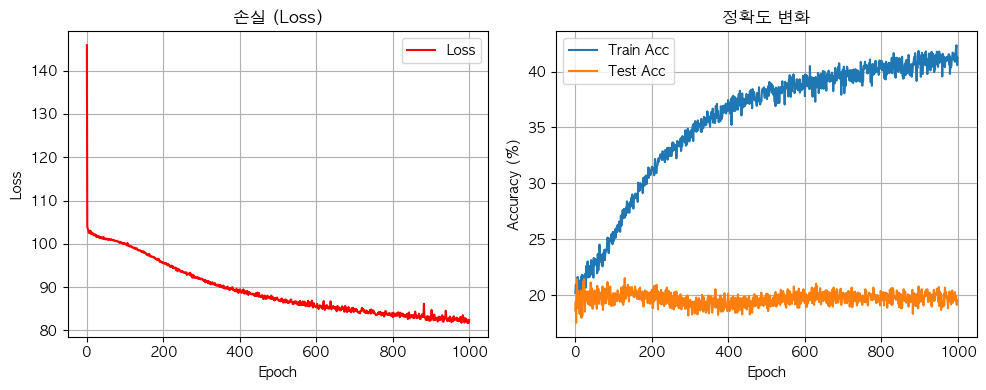

[1000/1000] 손실=82.416, 훈련=41.23%, 테스트=19.53%

💾 모델 저장 완료: jackpot_model.pth


'\n실행시키면 test data에 대한 정확도는 안올라가는데 이것이 올라가게 된다면 성능이 보장된것이다(현재 학습방법은 기본 게임한때 보던 임베딩벡터를 mlp모델에 단순 학습시킨상태이다)\n학습데이터를 10000~50000개정도는 해야지 overfitting이 안일어나고 다양한 패턴을 학습할수있는 양일수있으나 정확한 필요 데이터이 양은 계산해보야야한다.\n'

In [127]:

# -----------------------------
# 5. 학습 설정
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = JackpotMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y, dtype=torch.long).to(device)

n_train = int(len(X_tensor) * 0.8)
X_train, X_test = X_tensor[:n_train], X_tensor[n_train:]
y_train, y_test = y_tensor[:n_train], y_tensor[n_train:]

EPOCHS = 1000
BATCH_SIZE = 128
train_accs, test_accs, losses = [], [], []

# -----------------------------
# 6. 실시간 그래프 학습 루프
# -----------------------------
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
import platform

# -----------------------------
# ✅ 한글 폰트 설정
# -----------------------------
if platform.system() == "Darwin":  # macOS
    rc('font', family='AppleGothic')
elif platform.system() == "Windows":
    rc('font', family='Malgun Gothic')
else:  # Linux (colab 등)
    rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 부호 깨짐 방지


plt.ion()
for epoch in range(EPOCHS):
    model.train()
    perm = torch.randperm(X_train.size(0))
    total_loss = 0

    for i in range(0, len(X_train), BATCH_SIZE):
        idx = perm[i:i+BATCH_SIZE]
        x_batch = X_train[idx]
        y_batch = y_train[idx]

        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # 평가
    model.eval()
    with torch.no_grad():
        preds_train = model(X_train).argmax(dim=1)
        preds_test = model(X_test).argmax(dim=1)
        acc_train = (preds_train == y_train).float().mean().item() * 100
        acc_test = (preds_test == y_test).float().mean().item() * 100

    train_accs.append(acc_train)
    test_accs.append(acc_test)
    losses.append(total_loss)

    # 실시간 그래프 업데이트
    clear_output(wait=True)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(losses, label="Loss", color="red")
    plt.title("손실 (Loss)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(train_accs, label="Train Acc")
    plt.plot(test_accs, label="Test Acc")
    plt.title("정확도 변화")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"[{epoch+1:03d}/{EPOCHS}] 손실={total_loss:.3f}, 훈련={acc_train:.2f}%, 테스트={acc_test:.2f}%")

plt.ioff()
torch.save(model.state_dict(), "jackpot_model.pth")
print("\n💾 모델 저장 완료: jackpot_model.pth")

'''
실행시키면 test data에 대한 정확도는 안올라가는데 이것이 올라가게 된다면 성능이 보장된것이다(현재 학습방법은 기본 게임한때 보던 임베딩벡터를 mlp모델에 단순 학습시킨상태이다)
학습데이터를 10000~50000개정도는 해야지 overfitting이 안일어나고 다양한 패턴을 학습할수있는 양일수있으나 정확한 필요 데이터이 양은 계산해보야야한다.
'''

# (2) 확률로 통합한 임베딩벡터를 이용해 MLP로 학습한 신경망

In [ ]:
# 각각 확률화한 기반으로 학습하는데 같은 확률로 확률화된 임베딩 벡터들 있어서 이부분을 학습이 일어난다면 그 순간의 다른 임베딩 벡터 요소들과 따로 병렬처리 학습 되도록한다.
  '''
  (확률로 먼저 판단을 시키고 출력은 예상구간이 나오게한다 그리고 그 상황을 임베딩 벡터들끼리 학습하게하여 어텐션 헤드가 이용되는것처럼한다?)
  '''

In [114]:
# 각 지표들(임베딩 요소들)이 어떻게 확률화 되었는지
'''
1. (0~4번째 구간분포) => 구간분포 126가지 경우의 횟수로 확률화(확률분포 파악)
2. (5~9번째 구간연속정도) => -30,..,-1,0,1,.. 과같이 나오는 정수들의 드문정도를 차지하는 비율로 확률화(확률분포)
3. (10~14번째 구간별횟수) => 사실상 구간을 두지않으면 효용성이 없어 구간을 10,20이렇게 두어보았는데 0~4번째 요소와 동일한 것으로 고려횟수만 달라진것이다 연쇄적용가능성 고려해보자
4. (15번째 사라지는구간) => 사라지는 구간에서 젝팟이 터질확률은 20%로 원래 모든구간에서 젝팟이 터질확률이 20%인것을 감안하면 있으나 마나한 데이터일수있다.
5. (16~18번째 5,10,20평균) => 평균으로부터 얼마나떨어졌는지를 domain으로 각 domain 요소들을 count해서 확률화(확률분포)
6. (19번째 CDF(확률)) => 이미 확률상태이다.
'''

# 실재 상황에서 저장된 모델(학습된 신경망)이용해 배팅해보기

In [90]:
import torch
import numpy as np
import random

# === 1. 동일한 환경 정의 (intervals, 함수 등) ===
intervals = [(1, 28), (29, 64), (65, 115), (116, 200), (201, float('inf'))]

def make_jackpot_num():
    jackpot_num = 1
    while True:
        if random.randint(1, 125) == 1:
            return jackpot_num
        jackpot_num += 1

def classify_interval(x):
    for i, (lo, hi) in enumerate(intervals):
        if lo <= x <= hi:
            return i
    return None

def generate_embedding(history):
    """이전 잭팟 기록으로 확률 임베딩 생성"""
    n = len(intervals)
    counts = [0] * n
    for x in history[-5:]:
        idx = classify_interval(x)
        if idx is not None:
            counts[idx] += 1
    counts = [c / 5 for c in counts]

    streaks = [random.random() for _ in range(n)]
    streaks = [s / sum(streaks) for s in streaks]

    diff = max(counts) - min(counts)
    diff_vec = [diff] * n
    diff_vec = [d / (max(diff_vec)+1e-6) for d in diff_vec]

    disappear = [random.random()]
    avg = np.mean(history[-20:]) if len(history) >= 20 else np.mean(history)
    diff_from_125 = abs(avg - 125)
    avg_probs = [min(1, diff_from_125 / 200)] * 3
    imbalance = [np.std(counts)]

    return np.array(counts + streaks + diff_vec + disappear + avg_probs + imbalance)

# === 2. 모델 구조 (학습 당시와 동일해야 함) ===
import torch.nn as nn
class JackpotMLP(nn.Module):
    def __init__(self, input_dim=20, hidden_dim=64, output_dim=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, x):
        return self.net(x)

# === 3. 저장된 모델 불러오기 ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = JackpotMLP().to(device)
model.load_state_dict(torch.load("jackpot_model.pth", map_location=device))
model.eval()

print("✅ 학습된 모델 로드 완료: jackpot_model.pth")

# === 4. 예측 함수 ===
def predict_new_embedding(new_embedding):
    with torch.no_grad():
        x_tensor = torch.tensor(new_embedding, dtype=torch.float32).unsqueeze(0).to(device)
        output = model(x_tensor)
        probs = torch.softmax(output, dim=1).cpu().numpy().flatten()
        return probs

# === 5. 실험 루프 ===
N_EXPERIMENTS = 10   # 원하는 만큼 실험 반복 가능
print(f"\n🎯 총 {N_EXPERIMENTS}회 예측-검증 시뮬레이션을 시작합니다.\n")

correct = 0

for i in range(N_EXPERIMENTS):
    # (1) 이전 잭팟 히스토리 30개 생성
    history = [make_jackpot_num() for _ in range(30)]

    # (2) 현재 상태의 임베딩 생성
    new_emb = generate_embedding(history)

    # (3) 모델 예측
    probs = predict_new_embedding(new_emb)
    predicted_class = np.argmax(probs)

    # (4) 실제 젝팟 생성 및 구간 판정
    real_jackpot = make_jackpot_num()
    real_class = classify_interval(real_jackpot)

    # (5) 비교 출력
    print(f"--- [{i+1}/{N_EXPERIMENTS}] ---")
    print(f"🧠 예측 확률 분포:")
    for j, p in enumerate(probs):
        lo, hi = intervals[j]
        mark = "← 예측" if j == predicted_class else ""
        print(f"구간{j+1} ({lo}~{hi}): {p*100:.2f}% {mark}")

    lo, hi = intervals[real_class]
    print(f"\n🎯 실제 젝팟 구간: {real_class+1} ({lo}~{hi}), 잭팟 수: {real_jackpot}")

    if real_class == predicted_class:
        print("✅ 예측 적중!")
        correct += 1
    else:
        print("❌ 예측 빗나감.")
    print("-------------------------------\n")

# === 6. 최종 정확도 요약 ===
print(f"📈 총 {N_EXPERIMENTS}회 중 {correct}회 적중 ({correct/N_EXPERIMENTS*100:.1f}%)")


✅ 학습된 모델 로드 완료: jackpot_model.pth

🎯 총 10회 예측-검증 시뮬레이션을 시작합니다.

--- [1/10] ---
🧠 예측 확률 분포:
구간1 (1~28): 16.48% 
구간2 (29~64): 19.13% 
구간3 (65~115): 19.89% 
구간4 (116~200): 23.24% ← 예측
구간5 (201~inf): 21.26% 

🎯 실제 젝팟 구간: 3 (65~115), 잭팟 수: 79
❌ 예측 빗나감.
-------------------------------

--- [2/10] ---
🧠 예측 확률 분포:
구간1 (1~28): 25.87% ← 예측
구간2 (29~64): 23.79% 
구간3 (65~115): 21.15% 
구간4 (116~200): 15.03% 
구간5 (201~inf): 14.16% 

🎯 실제 젝팟 구간: 2 (29~64), 잭팟 수: 58
❌ 예측 빗나감.
-------------------------------

--- [3/10] ---
🧠 예측 확률 분포:
구간1 (1~28): 28.37% ← 예측
구간2 (29~64): 17.39% 
구간3 (65~115): 18.06% 
구간4 (116~200): 19.70% 
구간5 (201~inf): 16.47% 

🎯 실제 젝팟 구간: 2 (29~64), 잭팟 수: 48
❌ 예측 빗나감.
-------------------------------

--- [4/10] ---
🧠 예측 확률 분포:
구간1 (1~28): 43.89% ← 예측
구간2 (29~64): 13.23% 
구간3 (65~115): 12.17% 
구간4 (116~200): 17.64% 
구간5 (201~inf): 13.07% 

🎯 실제 젝팟 구간: 1 (1~28), 잭팟 수: 27
✅ 예측 적중!
-------------------------------

--- [5/10] ---
🧠 예측 확률 분포:
구간1 (1~28): 24.09% 
구간2 (29~64): 15.18% 
구간3 (

# <본격적으로 신경망을 설계해 성능을 높여보자>

In [135]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import random
import math

# ============================================================
# Device 설정 (Mac 최적화)
# ============================================================

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("🔥 Using Apple GPU (MPS) acceleration")
else:
    device = torch.device("cpu")
    print("➡️ Using CPU")

# CPU 병렬 연산 최적화
torch.set_num_threads(8)

# ============================================================
# 1. 게임 관련 함수들
# ============================================================

intervals = [(1,28),(29,64),(65,115),(116,200),(201,float('inf'))] # 범위를 (201,1200)으로 했으때 그것보다 큰 숫자 나왔을때 none error 나왔었음
p = 1/125
q = 1 - p

def make_jackpot_num():
    jackpot_num = 1
    while True:
        if random.randint(1,125)==1:
            return jackpot_num
        jackpot_num+=1

def classify_interval(x, intervals):
    for i,(lo,hi) in enumerate(intervals):
        if lo<=x<=hi:
            return i
    return None

def interval_distribution(nums, intervals, n):
    recent = nums[-n:]
    counts = [0]*len(intervals)
    for num in recent:
        idx = classify_interval(num, intervals)
        if idx is not None:
            counts[idx]+=1
    return counts

def signed_streaks_by_interval(nums, intervals):
    seq = [classify_interval(x, intervals) for x in nums]
    m=len(intervals)
    L=len(seq)
    if L==0:
        return [0]*m
    streaks = []
    for target in range(m):
        if seq[-1]==target:
            r=0; j=L-1
            while j>=0 and seq[j]==target:
                r+=1; j-=1
            streaks.append(+r)
        else:
            g=0; j=L-1
            while j>=0 and seq[j]!=target:
                g+=1; j-=1
            streaks.append(-g)
    return streaks

def moving_average(nums, n):
    if len(nums)==0:
        return 0
    s = nums[-n:] if len(nums)>=n else nums
    return sum(s)/len(s)



# ============================================================
# 2. 토큰 생성
# ============================================================

def extract_tokens(jackpot_list):
    tokens = []

    # ① 최근 구간 분포 (4 tokens, dim=5)
    for n in [5,10,15,20]:
        dist = interval_distribution(jackpot_list, intervals, n)
        tokens.append(torch.tensor(dist, dtype=torch.float32))

    # ② 평균 (4 tokens, dim=1)
    for n in [5,10,15,20]:
        avg = moving_average(jackpot_list, n)
        tokens.append(torch.tensor([avg], dtype=torch.float32))

    # ③ 스트릭 (5 tokens, dim=1)
    streaks = signed_streaks_by_interval(jackpot_list, intervals)
    for s in streaks:
        tokens.append(torch.tensor([s], dtype=torch.float32))

    # ④ CDF (1 token, dim=1)
    play_num = len(jackpot_list) if len(jackpot_list)>0 else 1
    cdfp = (1 - (q**play_num))
    tokens.append(torch.tensor([cdfp], dtype=torch.float32))

    return tokens   # list of 14 tokens



# ============================================================
# 3. Transformer Model
# ============================================================

class SlotTransformer(nn.Module):
    def __init__(self, embed_dim=16, num_heads=4, num_classes=5):
        super().__init__()
        self.num_tokens = 14

        self.embed_5d = nn.Linear(5, embed_dim)
        self.embed_1d = nn.Linear(1, embed_dim)

        self.position = nn.Parameter(torch.randn(self.num_tokens, embed_dim))

        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=128,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=2)

        self.fc = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, tokens):
        # tokens: (B, 14, 5)
        B = tokens.size(0)

        embedded = []
        for i in range(self.num_tokens):
            t = tokens[:,i,:]
            if t.shape[1] == 5:      # real 5D token
                embedded.append(self.embed_5d(t))
            else:                    # padded 1D token
                embedded.append(self.embed_1d(t[:,0:1]))

        x = torch.stack(embedded, dim=1)
        x = x + self.position

        h = self.encoder(x)
        h_mean = h.mean(dim=1)

        logits = self.fc(h_mean)
        return logits



# ============================================================
# 4. Dataset (자동 시뮬레이션)
# ============================================================

class SlotDataset(Dataset):
    def __init__(self, size=30000):
        self.X=[]
        self.y=[]

        for _ in range(size):
            jackpot_list=[]
            jackpot_num=make_jackpot_num()
            target = classify_interval(jackpot_num, intervals)

            for i in range(1,jackpot_num+1):
                jackpot_list.append(i)

            tokens = extract_tokens(jackpot_list)

            padded = []
            for t in tokens:
                if t.shape[0] == 5:
                    padded.append(t)
                else:
                    padded.append(torch.tensor([t[0],0,0,0,0], dtype=torch.float32))
            padded = torch.stack(padded)

            self.X.append(padded)
            self.y.append(target)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]



# ============================================================
# 5. Training Loop (Mac 안전 버전)
# ============================================================

from tqdm import tqdm

def train_model():
    dataset = SlotDataset(size=20000)
    loader = DataLoader(dataset, batch_size=64, shuffle=True,
                        num_workers=0, pin_memory=False)

    model = SlotTransformer().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(5):
        print(f"\n===== Epoch {epoch+1} / 5 =====")

        epoch_loss = 0
        correct = 0
        total = 0

        # tqdm progress bar 표시
        for X, y in tqdm(loader, desc="Training"):
            X = X.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            logits = model(X)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            optimizer.step()

            # 배치 평균 loss 계산
            epoch_loss += loss.item()

            # accuracy 계산
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

        avg_loss = epoch_loss / len(loader)
        accuracy = correct / total * 100

        print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")

    return model



# =============================
# 실행
# =============================
model = train_model()


🔥 Using Apple GPU (MPS) acceleration

===== Epoch 1 / 5 =====


Training: 100%|███████████████████████████████| 313/313 [00:03<00:00, 88.98it/s]


Epoch 1 | Loss: 0.2302 | Accuracy: 95.25%

===== Epoch 2 / 5 =====


Training: 100%|███████████████████████████████| 313/313 [00:03<00:00, 98.37it/s]


Epoch 2 | Loss: 0.0013 | Accuracy: 100.00%

===== Epoch 3 / 5 =====


...

Epoch 3 | Loss: 0.0044 | Accuracy: 99.89%

===== Epoch 4 / 5 =====


Training: 100%|███████████████████████████████| 313/313 [00:03<00:00, 98.64it/s]


Epoch 4 | Loss: 0.0003 | Accuracy: 100.00%

===== Epoch 5 / 5 =====


Training: 100%|██████████████████████████████| 313/313 [00:03<00:00, 100.09it/s]

Epoch 5 | Loss: 0.0007 | Accuracy: 99.98%


In [ ]:
# 위 코드와 비교해 예측기능, validation데이터 추가, 어텐션 시각화부분 추가

In [138]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import random
import math
from tqdm import tqdm

# ============================================================
# Device 설정 (Mac 최적화)
# ============================================================

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("🔥 Using Apple GPU (MPS) acceleration")
else:
    device = torch.device("cpu")
    print("➡️ Using CPU")

torch.set_num_threads(8)


# ============================================================
# 1. 게임 관련 함수들
# ============================================================

intervals = [(1,28),(29,64),(65,115),(116,200),(201,float('inf'))]
p = 1/125
q = 1 - p

def make_jackpot_num():
    jackpot_num = 1
    while True:
        if random.randint(1,125)==1:
            return jackpot_num
        jackpot_num+=1

def classify_interval(x, intervals):
    for i,(lo,hi) in enumerate(intervals):
        if lo<=x<=hi:
            return i
    return None

def interval_distribution(nums, intervals, n):
    recent = nums[-n:]
    counts = [0]*len(intervals)
    for num in recent:
        idx = classify_interval(num, intervals)
        if idx is not None:
            counts[idx]+=1
    return counts

def signed_streaks_by_interval(nums, intervals):
    seq = [classify_interval(x, intervals) for x in nums]
    m=len(intervals)
    L=len(seq)
    if L==0:
        return [0]*m
    streaks = []
    for target in range(m):
        if seq[-1]==target:
            r=0; j=L-1
            while j>=0 and seq[j]==target:
                r+=1; j-=1
            streaks.append(+r)
        else:
            g=0; j=L-1
            while j>=0 and seq[j]!=target:
                g+=1; j-=1
            streaks.append(-g)
    return streaks

def moving_average(nums, n):
    if len(nums)==0:
        return 0
    s = nums[-n:] if len(nums)>=n else nums
    return sum(s)/len(s)


# ============================================================
# 2. 토큰 생성
# ============================================================

def extract_tokens(jackpot_list):
    tokens = []

    # 최근 구간 분포 (4 tokens, 5D)
    for n in [5,10,15,20]:
        dist = interval_distribution(jackpot_list, intervals, n)
        tokens.append(torch.tensor(dist, dtype=torch.float32))

    # 평균 (4 tokens, 1D)
    for n in [5,10,15,20]:
        avg = moving_average(jackpot_list, n)
        tokens.append(torch.tensor([avg], dtype=torch.float32))

    # 스트릭 (5 tokens, 1D)
    streaks = signed_streaks_by_interval(jackpot_list, intervals)
    for s in streaks:
        tokens.append(torch.tensor([s], dtype=torch.float32))

    # CDF (1 token, 1D)
    play_num = len(jackpot_list) if len(jackpot_list)>0 else 1
    cdfp = (1 - (q**play_num))
    tokens.append(torch.tensor([cdfp], dtype=torch.float32))

    return tokens


# ============================================================
# 3. Transformer — Attention 추출 가능한 레이어 (⭐ 최신 PyTorch 호환)
# ============================================================

class TransformerEncoderLayerWithAttn(nn.TransformerEncoderLayer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.attn_weights = None

    # ⭐ PyTorch 2.1+ 요구 시그니처: is_causal 포함해야 함
    def _sa_block(self, x, attn_mask=None, key_padding_mask=None, is_causal=False):
        out, attn = self.self_attn(
            x, x, x,
            attn_mask=attn_mask,
            key_padding_mask=key_padding_mask,
            need_weights=True,
            average_attn_weights=False,
            is_causal=is_causal
        )
        self.attn_weights = attn
        return self.dropout1(out)


class SlotTransformer(nn.Module):
    def __init__(self, embed_dim=16, num_heads=4, num_classes=5):
        super().__init__()
        self.num_tokens = 14

        self.embed_5d = nn.Linear(5, embed_dim)
        self.embed_1d = nn.Linear(1, embed_dim)

        self.position = nn.Parameter(torch.randn(self.num_tokens, embed_dim))

        self.encoder_layer = TransformerEncoderLayerWithAttn(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=128,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=2)

        self.fc = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, tokens):
        embedded = []
        for i in range(self.num_tokens):
            t = tokens[:,i,:]
            if t.shape[1] == 5:
                embedded.append(self.embed_5d(t))
            else:
                embedded.append(self.embed_1d(t[:,0:1]))

        x = torch.stack(embedded, dim=1)
        x = x + self.position

        h = self.encoder(x)
        h_mean = h.mean(dim=1)

        logits = self.fc(h_mean)
        return logits


# ============================================================
# 4. Dataset
# ============================================================

class SlotDataset(Dataset):
    def __init__(self, size=30000):
        self.X=[]
        self.y=[]

        for _ in range(size):
            jackpot_list=[]
            jackpot_num=make_jackpot_num()
            target = classify_interval(jackpot_num, intervals)

            for i in range(1,jackpot_num+1):
                jackpot_list.append(i)

            tokens = extract_tokens(jackpot_list)

            padded=[]
            for t in tokens:
                if t.shape[0]==5:
                    padded.append(t)
                else:
                    padded.append(torch.tensor([t[0],0,0,0,0], dtype=torch.float32))

            self.X.append(torch.stack(padded))
            self.y.append(target)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ============================================================
# 5. Train + Validation
# ============================================================

def get_loaders():
    full = SlotDataset(size=20000)
    train_size = int(len(full)*0.8)
    val_size = len(full) - train_size
    train_set, val_set = random_split(full, [train_size, val_size])

    train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
    val_loader   = DataLoader(val_set, batch_size=64, shuffle=False)
    return train_loader, val_loader


def train_model():
    train_loader, val_loader = get_loaders()
    model = SlotTransformer().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(5):
        print(f"\n===== Epoch {epoch+1} / 5 =====")

        # TRAIN
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0

        for X, y in tqdm(train_loader, desc="Train"):
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(X)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_correct += (logits.argmax(1)==y).sum().item()
            train_total += y.size(0)

        # VALIDATION
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for X, y in tqdm(val_loader, desc="Val "):
                X, y = X.to(device), y.to(device)

                logits = model(X)
                loss = F.cross_entropy(logits, y)

                val_loss += loss.item()
                val_correct += (logits.argmax(1)==y).sum().item()
                val_total += y.size(0)

        print(f"Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: {train_correct/train_total*100:.2f}%")
        print(f" Val  Loss: {val_loss/len(val_loader):.4f} |  Val Acc: {val_correct/val_total*100:.2f}%")

    return model


# ============================================================
# 6. 예측 함수
# ============================================================

def predict_interval(model, jackpot_list):
    model.eval()
    tokens = extract_tokens(jackpot_list)

    padded=[]
    for t in tokens:
        if t.shape[0]==5:
            padded.append(t)
        else:
            padded.append(torch.tensor([t[0],0,0,0,0], dtype=torch.float32))

    X = torch.stack(padded).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(X)
        probs = torch.softmax(logits, dim=-1)
        pred = probs.argmax(dim=1).item()

    return pred, probs.cpu().numpy()


# ============================================================
# 7. Attention 시각화
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

def visualize_attention(model, jackpot_list):
    model.eval()
    tokens = extract_tokens(jackpot_list)

    padded=[]
    for t in tokens:
        if t.shape[0]==5:
            padded.append(t)
        else:
            padded.append(torch.tensor([t[0],0,0,0,0], dtype=torch.float32))

    X = torch.stack(padded).unsqueeze(0).to(device)

    with torch.no_grad():
        _ = model(X)

    attn = model.encoder_layer.attn_weights
    attn = attn.mean(dim=0)[0]

    plt.figure(figsize=(10,7))
    sns.heatmap(attn.cpu(), cmap='viridis')
    plt.title("Attention Heatmap (14 Tokens)")
    plt.xlabel("Key")
    plt.ylabel("Query")
    plt.show()


# ============================================================
# 실행
# ============================================================

model = train_model()


🔥 Using Apple GPU (MPS) acceleration

===== Epoch 1 / 5 =====


Val : 100%|████████████████████████████████████| 63/63 [00:00<00:00, 279.58it/s]


Train Loss: 0.2636 | Train Acc: 95.57%
 Val  Loss: 0.0022 |  Val Acc: 100.00%

===== Epoch 2 / 5 =====


Val : 100%|████████████████████████████████████| 63/63 [00:00<00:00, 285.95it/s]


Train Loss: 0.0029 | Train Acc: 99.99%
 Val  Loss: 0.0005 |  Val Acc: 100.00%

===== Epoch 3 / 5 =====


...

Train Loss: 0.0010 | Train Acc: 99.99%
 Val  Loss: 0.0002 |  Val Acc: 100.00%

===== Epoch 4 / 5 =====


Val : 100%|████████████████████████████████████| 63/63 [00:00<00:00, 286.67it/s]


Train Loss: 0.0003 | Train Acc: 100.00%
 Val  Loss: 0.0001 |  Val Acc: 100.00%

===== Epoch 5 / 5 =====


Val : 100%|████████████████████████████████████| 63/63 [00:00<00:00, 289.45it/s]

Train Loss: 0.0038 | Train Acc: 99.91%
 Val  Loss: 0.0001 |  Val Acc: 100.00%


In [139]:
#만 약 학습 후에 예측 테스트까지 하고 싶으면?
# 예시 jackpot_list
test_list = [1,2,3,4,5,6,7,8,9,10]

pred, prob = predict_interval(model, test_list)
print("예측된 구간:", pred)
print("확률 분포:", prob)


예측된 구간: 0
확률 분포: [[9.9995613e-01 2.1228736e-05 5.9308486e-06 2.4918029e-06 1.4220990e-05]]


In [140]:
# Attention heatmap까지 보고 싶으면?

visualize_attention(model, test_list)


AttributeError: 'NoneType' object has no attribute 'mean'

# 3. 이후 자동으로 게임을 수행하며 강화학습하는 알고리즘 만들기 

In [ ]:
# 배팅분류하고 더 나은 방향을 찾아 가중치를 수정할수있는 메커니즘 구현해야함